In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import h5py

import tensorflow as tf
import numpy as np
import healpy as hp
import matplotlib.pyplot as plt

from time import time
from icecream import ic

from msfm.utils import tfrecords, files, parameters
from msfm.fiducial_pipeline import FiducialPipeline
from msfm.utils.input_output import read_yaml

23-09-18 02:08:43    scales.py INF   Setting up healpy to run on 32 CPUs 


In [3]:
data_vec_pix, _, _, _ = files.load_pixel_file()
n_side = 512
n_pix = hp.nside2npix(n_side)

23-09-18 02:08:43     files.py INF   Loaded the pixel file /global/u2/a/athomsen/multiprobe-simulation-forward-model/data/DESY3_pixels_512.h5 


In [7]:
n_pix = hp.nside2npix(512)
# tfr_pattern = "/pscratch/sd/a/athomsen/DESY3/v4/large_scales/tfrecords/fiducial/DESy3_fiducial_000.tfrecord"
tfr_pattern = "/pscratch/sd/a/athomsen/DESY3/v4/grf/tfrecords/fiducial/DESy3_fiducial_000.tfrecord"

noisy_fid_pipe = FiducialPipeline(
    # params=["Om", "s8", "Aia", "bg", "n_Aia", "n_bg"],
    params=["Om", "s8", "bg", "n_bg"],
    with_lensing=False,
    with_clustering=True,
    with_padding=True,
    apply_norm=False,
    shape_noise_scale=1.0,
    poisson_noise_scale=1.0,
    z_bin_inds=None,
)

fiducial_dset = noisy_fid_pipe.get_dset(
    tfr_pattern=tfr_pattern,
    local_batch_size=1,
    n_noise=3,
    n_readers=1,
    examples_shuffle_buffer=16,
    n_prefetch=0,
    is_eval=False,
)

for data_vector, index in fiducial_dset.take(5):
    print(data_vector.shape)
    print(tf.squeeze(index))
#     print(index[0].numpy(), index[1].numpy())



23-09-18 02:09:41     files.py INF   Loaded the pixel file /global/u2/a/athomsen/multiprobe-simulation-forward-model/data/DESY3_pixels_512.h5 
23-09-18 02:09:42     files.py INF   Loaded the pixel file /global/u2/a/athomsen/multiprobe-simulation-forward-model/data/DESY3_pixels_512.h5 
23-09-18 02:09:42 fiducial_pip INF   Shuffling file names with shuffle_buffer = 16 
23-09-18 02:09:42 fiducial_pip INF   Interleaving with n_readers = 1 
23-09-18 02:09:42 fiducial_pip INF   Shuffling examples with shuffle_buffer = 16 
23-09-18 02:09:42 fiducial_pip INF   Batching into 1 elements locally 
23-09-18 02:09:42 fiducial_pip WAR   Tracing _augmentations 
23-09-18 02:09:42 fiducial_pip INF   Running on the data_vectors.keys() = dict_keys(['dg_fiducial', 'dg_delta_Om_m', 'dg_delta_Om_p', 'dg_delta_s8_m', 'dg_delta_s8_p', 'dg_delta_bg_m', 'dg_delta_bg_p', 'dg_delta_n_bg_m', 'dg_delta_n_bg_p', 'i_example', 'pn', 'i_noise']) 
23-09-18 02:09:42 fiducial_pip WAR   Tracing _clustering_augmentations 
23

InvalidArgumentError: cannot compute Pack as input #1(zero-based) was expected to be a int64 tensor but is a int32 tensor [Op:Pack] name: packed

In [4]:
n_pix = hp.nside2npix(512)
tfr_pattern = "/pscratch/sd/a/athomsen/DESY3/v4/large_scales/tfrecords/fiducial/DESy3_fiducial_000.tfrecord"

noisy_fid_pipe = FiducialPipeline(
    params=["Om", "s8", "Aia", "bg", "n_Aia", "n_bg"],
    with_lensing=True,
    with_clustering=True,
    with_padding=True,
    apply_norm=False,
    shape_noise_scale=1.0,
    poisson_noise_scale=1.0,
    z_bin_inds=None,
)

fiducial_dset = noisy_fid_pipe.get_dset(
    tfr_pattern=tfr_pattern,
    local_batch_size=10,
    n_noise=3,
    n_readers=1,
    examples_shuffle_buffer=None,
    n_prefetch=0,
    is_eval=True,
)

for data_vector, index in fiducial_dset.take(5):
    print(index[0].numpy(), index[1].numpy())


23-09-05 06:41:14     files.py INF   Loaded the pixel file /global/u2/a/athomsen/multiprobe-simulation-forward-model/data/DESY3_pixels_512.h5 
23-09-05 06:41:14     files.py INF   Loaded the pixel file /global/u2/a/athomsen/multiprobe-simulation-forward-model/data/DESY3_pixels_512.h5 
23-09-05 06:41:16 fiducial_pip WAR   Evaluation mode is activated: the random seed is fixed, the shuffle arguments ignored, and the dataset is not repeated 
23-09-05 06:41:16 fiducial_pip INF   Interleaving with n_readers = 1 


/global/common/software/des/athomsen/dlss/lib/python3.9/site-packages/tensorflow/python/data/ops/dataset_ops.py:2210: UserWarning: The `deterministic` argument has no effect unless the `num_parallel_calls` argument is specified.
  warnings.warn("The `deterministic` argument has no effect unless the "


23-09-05 06:41:16 fiducial_pip INF   Batching into 10 elements locally 
23-09-05 06:41:17 fiducial_pip WAR   Tracing _augmentations 
Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: module, class, method, function, traceback, frame, or code object was expected, got cython_function_or_method
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: module, class, method, function, traceback, frame, or code object was expected, got cython_function_or_method
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
23-09-05 06:41:18 fiducial_pip INF   Running on the data_vectors.keys() = dict_keys(['kg_fiducial', 'dg_fiducial', 'kg_delta_

# multiple noise realizations

In [ ]:
n_pix = hp.nside2npix(512)
tfr_pattern = "/cluster/scratch/athomsen/CosmoGrid/v4/debug/fiducial/DESy3_fiducial_000.tfrecord"

noiseless_fid_pipe = FiducialPipeline(
    params=["Om", "s8", "Aia", "bg", "n_Aia", "n_bg"],
    with_lensing=True,
    with_clustering=True,
    with_padding=True,
    apply_norm=False,
    shape_noise_scale=0,
    poisson_noise_scale=0,    
)

noisy_fid_pipe = FiducialPipeline(
    params=["Om", "s8", "Aia", "bg", "n_Aia", "n_bg"],
    with_lensing=True,
    with_clustering=True,
    with_padding=True,
    apply_norm=False,
    shape_noise_scale=1.0,
    poisson_noise_scale=1.0,    
)

In [15]:
fiducial_dset = noiseless_fid_pipe.get_dset(
    tfr_pattern=tfr_pattern,
    local_batch_size=1,
    i_noise=0,
    n_readers=1,
    examples_shuffle_buffer=None,
    n_prefetch=0,
    is_eval=True,
)

# get a single batch
for data_vector, index in fiducial_dset.take(1):
    dv_noiseless = data_vector

dvs_noisy = []

for i_noise in range(3):
    fiducial_dset = noisy_fid_pipe.get_dset(
        tfr_pattern=tfr_pattern,
        local_batch_size=1,
        i_noise=i_noise,
        n_readers=1,
        examples_shuffle_buffer=None,
        n_prefetch=0,
        is_eval=True,
    )

    # get a single batch
    for data_vector, index in fiducial_dset.take(1):
        dvs_noisy.append(data_vector)

23-08-22 10:08:34 fiducial_pip WAR   Evaluation mode is activated, the random seed is fixed and the dataset is not repeated 
23-08-22 10:08:34 tfrecords.py WAR   Tracing parse_inverse_fiducial 
23-08-22 10:08:35 fiducial_pip INF   Batching into 1 elements locally 
23-08-22 10:08:35 fiducial_pip WAR   Tracing _augmentations 
23-08-22 10:08:35 fiducial_pip INF   Running on the data_vectors.keys() = dict_keys(['kg_fiducial', 'dg_fiducial', 'kg_delta_Om_m', 'dg_delta_Om_m', 'kg_delta_Om_p', 'dg_delta_Om_p', 'kg_delta_s8_m', 'dg_delta_s8_m', 'kg_delta_s8_p', 'dg_delta_s8_p', 'kg_delta_Aia_m', 'kg_delta_Aia_p', 'dg_delta_bg_m', 'dg_delta_bg_p', 'kg_delta_n_Aia_m', 'kg_delta_n_Aia_p', 'dg_delta_n_bg_m', 'dg_delta_n_bg_p', 'sn', 'pn']) 
23-08-22 10:08:35 fiducial_pip WAR   Tracing _lensing_augmentations 
23-08-22 10:08:35 fiducial_pip WAR   Tracing _clustering_augmentations 
23-08-22 10:08:35 fiducial_pip INF   Successfully generated the fiducial training set with element_spec (TensorSpec(shap

### compare noise realizations to noiseless

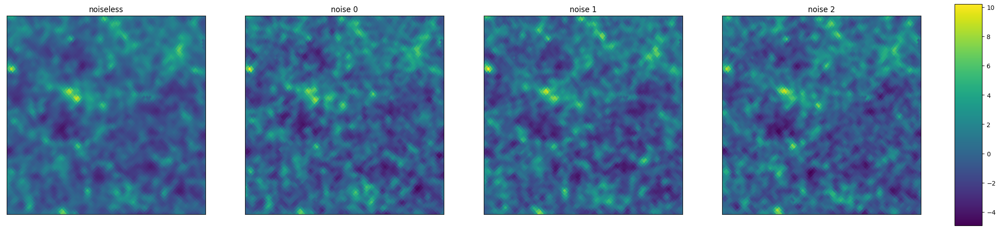

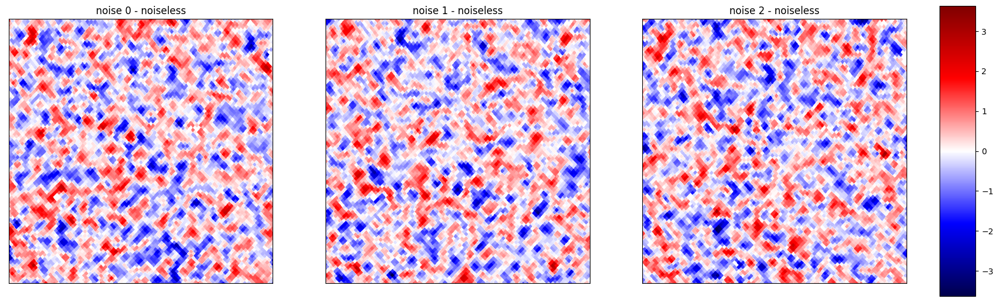

In [16]:
i_tomo = 7

# absolute maps
gnoms = []

hp_map = np.full(n_pix, hp.UNSEEN)
hp_map[noiseless_fid_pipe.data_vec_pix] = dv_noiseless[0,:,i_tomo]

# hp.mollview(hp_map, nest=True)
gnom = hp.gnomview(hp_map, nest=True, rot=(90, -30, 0), reso=1, xsize=600, ysize=600, return_projected_map=True, no_plot=True)
gnoms.append(gnom)

for dv_noisy in dvs_noisy:
    hp_map = np.full(n_pix, hp.UNSEEN)
    hp_map[noiseless_fid_pipe.data_vec_pix] = dv_noisy[0,:,i_tomo]
    
    # hp.mollview(hp_map, nest=True)
    gnom = hp.gnomview(hp_map, nest=True, rot=(90, -30, 0), reso=1, xsize=600, ysize=600, return_projected_map=True, no_plot=True)
    gnoms.append(gnom)
    
fig, ax = plt.subplots(figsize=(8*len(gnoms), 8), ncols=len(gnoms))

vmin = np.array(gnoms).min()
vmax = np.array(gnoms).max()

titles = ["noiseless", "noise 0", "noise 1", "noise 2"]

for i, gnom in enumerate(gnoms):
    im = ax[i].imshow(gnom, vmin=vmin, vmax=vmax)
    
    ax[i].set_xticks([])
    ax[i].set_yticks([])
    ax[i].set(title=titles[i])
    
fig.colorbar(im, ax=ax, orientation="vertical", shrink=0.8, aspect=8, pad=0.03)

# difference to noiseless
gnoms = []

for dv_noisy in dvs_noisy:
    hp_map = np.full(n_pix, hp.UNSEEN)
    hp_map[noiseless_fid_pipe.data_vec_pix] = dv_noiseless[0,:,i_tomo] - dv_noisy[0,:,i_tomo]
    
    # hp.mollview(hp_map, nest=True)
    gnom = hp.gnomview(hp_map, nest=True, rot=(90, -30, 0), reso=1, xsize=600, ysize=600, return_projected_map=True, no_plot=True)
    gnoms.append(gnom)
    
fig, ax = plt.subplots(figsize=(8*len(gnoms), 8), ncols=len(gnoms))

vmin = - np.max([np.abs(np.array(gnoms).min()), np.abs(np.array(gnoms).max())])
vmax = np.max([np.abs(np.array(gnoms).min()), np.abs(np.array(gnoms).max())])

titles = ["noise 0 - noiseless", "noise 1 - noiseless", "noise 2 - noiseless"]

for i, gnom in enumerate(gnoms):
    im = ax[i].imshow(gnom, vmin=vmin, vmax=vmax, cmap="seismic")
    
    ax[i].set_xticks([])
    ax[i].set_yticks([])
    ax[i].set(title=titles[i])

fig.colorbar(im, ax=ax, orientation="vertical", shrink=0.8, aspect=8, pad=0.03)

### check derivatives

In [17]:
dvs_noisy[0].shape

TensorShape([13, 464896, 8])

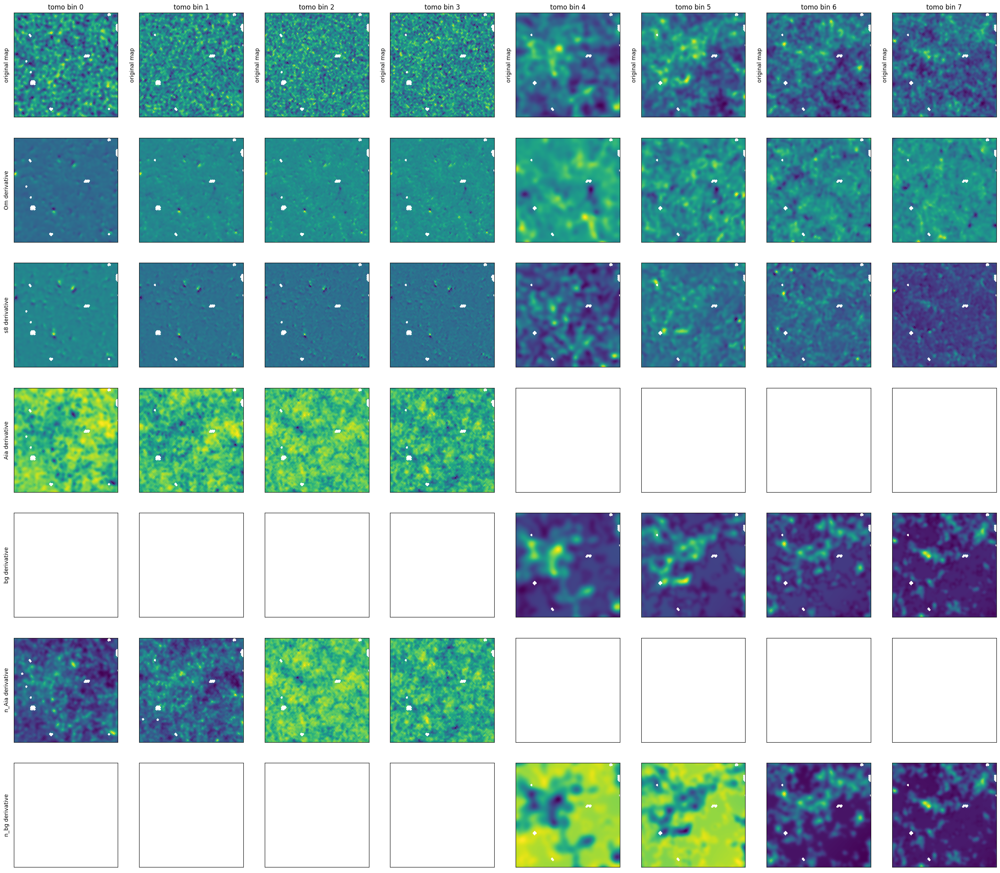

In [20]:
# fix noise realization, shape (2*n_params+1, n_pix, n_z)
dv_noisy = dvs_noisy[0]
params = noiseless_fid_pipe.params
data_vec_pix = noiseless_fid_pipe.data_vec_pix
n_z = noiseless_fid_pipe.n_z_metacal + noiseless_fid_pipe.n_z_maglim

fig, ax = plt.subplots(figsize=(4*n_z, 4*(len(params)+1)), nrows=len(params)+1, ncols=n_z) 

for i_z in range(n_z):
    hp_map = np.zeros(n_pix)
    hp_map[data_vec_pix] = dv_noisy[0,:,i_z]
    gnom = hp.gnomview(hp_map, nest=True, rot=(90, -30, 0), reso=1, xsize=600, ysize=600, return_projected_map=True, no_plot=True)
    gnom = np.ma.masked_where(gnom==0, gnom)

    ax[0,i_z].imshow(gnom)
    
    # cosmetics
    ax[0,i_z].set_xticks([])
    ax[0,i_z].set_yticks([])
    ax[0,i_z].set(title=f"tomo bin {i_z}", ylabel="original map")

for i_p, param in enumerate(params):
    for i_z in range(n_z):
        hp_minus = np.zeros(n_pix)
        hp_minus[data_vec_pix] = dv_noisy[2*i_p+1,:,i_z]

        hp_plus = np.full(n_pix, hp.UNSEEN)
        hp_plus[data_vec_pix] = dv_noisy[2*i_p+2,:,i_z]

        gnom = hp.gnomview(hp_plus - hp_minus, nest=True, rot=(90, -30, 0), reso=1, xsize=600, ysize=600, return_projected_map=True, no_plot=True)
        gnom = np.ma.masked_where(gnom==0, gnom)

        ax[i_p+1,i_z].imshow(gnom)

        # cosmetics
        ax[i_p+1,i_z].set_xticks([])
        ax[i_p+1,i_z].set_yticks([])
        
    ax[i_p+1,0].set(ylabel=f"{param} derivative")


In [ ]:
l_max_list = [723, 1054, 1408, 1535, 328, 478, 621, 739]
l_max = l_max_list[i_tomo]
print(f"Using smoothing scale {l_max}")

hp_noiseless = np.zeros(n_pix)
hp_noiseless[noiseless_fid_pipe.data_vec_pix] = dv_noiseless[0,:,i_tomo]
smoothed_hp_noiseless = hp.smoothing(hp_noiseless, fwhm=np.pi/l_max, nest=True, use_pixel_weights=True, pol=False)

gnoms = []
gnoms.append(hp.gnomview(hp_noiseless, nest=True, rot=(90, -30, 0), reso=1, xsize=600, ysize=600, return_projected_map=True, no_plot=True, title="noiseless (non smoothed)"))
gnoms.append(hp.gnomview(smoothed_hp_noiseless, nest=True, rot=(90, -30, 0), reso=1, xsize=600, ysize=600, return_projected_map=True, no_plot=True, title="noiseless (smoothed)"))
gnoms.append(hp.gnomview(hp_noiseless - smoothed_hp_noiseless, nest=True, rot=(90, -30, 0), reso=1, xsize=600, ysize=600, return_projected_map=True, no_plot=True, title="noiseless difference"))

vmin = np.array(gnoms).min()
vmax = np.array(gnoms).max()

titles = ["original", "smoothed", "difference"]

fig, ax = plt.subplots(figsize=(8*len(gnoms), 8), ncols=len(gnoms))
for i, gnom in enumerate(gnoms):
    ax[i].imshow(gnom, vmin=vmin, vmax=vmax)
    
    ax[i].set_xticks([])
    ax[i].set_yticks([])
    ax[i].set(title=titles[i])

fig.colorbar(im, ax=ax, orientation="vertical", shrink=0.8, aspect=8, pad=0.03)

# hp_noisy = []
# for dv_noisy in dvs_noisy:
#     hp_map = np.full(n_pix, hp.UNSEEN)
#     hp_map[noiseless_fid_pipe.data_vec_pix] = dv_noisy[0,:,i_tomo]
#     hp_noisy.append(hp_map)

# for i, hp_map in enumerate(hp_noisy):
#     smoothed_hp = hp.smoothing(hp_map, fwhm=np.pi/l_max[i_tomo])
#     hp.mollview(hp_map - smoothed_hp, nest=True, title=f"noisy {i} smoothing difference")


# OLD

In [11]:
n_pix = hp.nside2npix(512)

fiducial_pipeline = FiducialPipeline(
    # with_padding=True,
    with_padding=False,
)

fiducial_dset = fiducial_pipeline.get_dset(
    tfr_pattern="/cluster/scratch/athomsen/CosmoGrid/v3/fiducial/DESy3_fiducial_???.tfrecord",
    local_batch_size=1,
    i_noise=0,
    n_readers=1,
    examples_shuffle_buffer=1,
)

# get a single batch
for data_vectors, index in fiducial_dset.take(1):
    hp_map = np.full(n_pix, hp.UNSEEN)
    
    # hp_map[fiducial_pipeline.data_vec_pix] = data_vectors[0,:,0]
    hp_map[fiducial_pipeline.patch_pix] = data_vectors[0,:,0]

    hp.mollview(hp_map, nest=True)

23-08-22 08:42:56     files.py INF   Loaded the pixel file /cluster/home/athomsen/py3_10/repos/multiprobe-simulation-forward-model/data/DESY3_pixels_512.h5 
23-08-22 08:42:56     files.py INF   Loaded the pixel file /cluster/home/athomsen/py3_10/repos/multiprobe-simulation-forward-model/data/DESY3_pixels_512.h5 


InvalidArgumentError: Expected 'tf.Tensor(False, shape=(), dtype=bool)' to be true. Summarized data: b'No files matched pattern: /cluster/scratch/athomsen/CosmoGrid/v3/fiducial/DESy3_fiducial_???.tfrecord'

23-05-22 15:45:43     files.py INF   Loaded the pixel file /cluster/home/athomsen/py3_10/repos/multiprobe-simulation-forward-model/data/DESY3_pixels_512.h5 
23-05-22 15:45:43     files.py INF   Loaded the pixel file /cluster/home/athomsen/py3_10/repos/multiprobe-simulation-forward-model/data/DESY3_pixels_512.h5 
23-05-22 15:45:43 fiducial_pip INF   Shuffling file names 
23-05-22 15:45:44 tfrecords.py WAR   Tracing parse_inverse_fiducial 
23-05-22 15:45:44 fiducial_pip INF   Batching into 1 elements locally 
23-05-22 15:45:44 fiducial_pip WAR   Tracing _augmentations 
23-05-22 15:45:44 fiducial_pip INF   Running on the data_vectors.keys() = dict_keys(['kg_fiducial', 'dg_fiducial', 'kg_delta_Om_m', 'dg_delta_Om_m', 'kg_delta_Om_p', 'dg_delta_Om_p', 'kg_delta_s8_m', 'dg_delta_s8_m', 'kg_delta_s8_p', 'dg_delta_s8_p', 'kg_delta_Aia_m', 'kg_delta_Aia_p', 'kg_delta_n_Aia_m', 'kg_delta_n_Aia_p', 'dg_delta_bg_m', 'dg_delta_bg_p', 'dg_delta_n_bg_m', 'dg_delta_n_bg_p', 'sn']) 
23-05-22 15:45:44 f

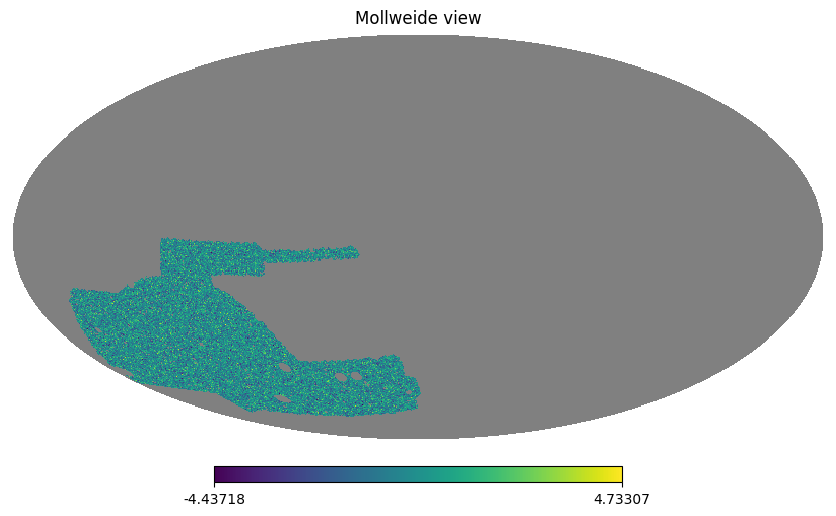

In [16]:
# create dataset
params = ["Om", "s8", "Aia", "n_Aia", "bg", "n_bg"]

fiducial_pipeline = FiducialPipeline(
    params=params,
    # shape_noise_scale=None,
    # apply_m_bias=True,
    # apply_norm=False,
    with_padding=False,
)

fiducial_dset = fiducial_pipeline.get_dset(
    tfr_pattern="/cluster/scratch/athomsen/CosmoGrid/v3/fiducial/DESy3_fiducial_???.tfrecord",
    local_batch_size=1,
    i_noise=0,
    n_readers=1,
    examples_shuffle_buffer=1,
)

# get a single batch
for data_vectors, index in fiducial_dset.take(1):
    hp_map = np.full(n_pix, hp.UNSEEN)
    hp_map[fiducial_pipeline.patch_pix] = data_vectors[0,:,0]
    
    hp.mollview(hp_map, nest=True)
    # print(data_vectors.shape)

23-05-22 15:45:13     files.py INF   Loaded the pixel file /cluster/home/athomsen/py3_10/repos/multiprobe-simulation-forward-model/data/DESY3_pixels_512.h5 
23-05-22 15:45:13     files.py INF   Loaded the pixel file /cluster/home/athomsen/py3_10/repos/multiprobe-simulation-forward-model/data/DESY3_pixels_512.h5 
23-05-22 15:45:14 fiducial_pip INF   Shuffling file names 
23-05-22 15:45:14 tfrecords.py WAR   Tracing parse_inverse_fiducial 
23-05-22 15:45:14 fiducial_pip INF   Batching into 1 elements locally 
23-05-22 15:45:14 fiducial_pip WAR   Tracing _augmentations 
23-05-22 15:45:14 fiducial_pip INF   Running on the data_vectors.keys() = dict_keys(['kg_fiducial', 'dg_fiducial', 'kg_delta_Om_m', 'dg_delta_Om_m', 'kg_delta_Om_p', 'dg_delta_Om_p', 'kg_delta_s8_m', 'dg_delta_s8_m', 'kg_delta_s8_p', 'dg_delta_s8_p', 'kg_delta_Aia_m', 'kg_delta_Aia_p', 'kg_delta_n_Aia_m', 'kg_delta_n_Aia_p', 'dg_delta_bg_m', 'dg_delta_bg_p', 'dg_delta_n_bg_m', 'dg_delta_n_bg_p', 'sn']) 
23-05-22 15:45:14 f

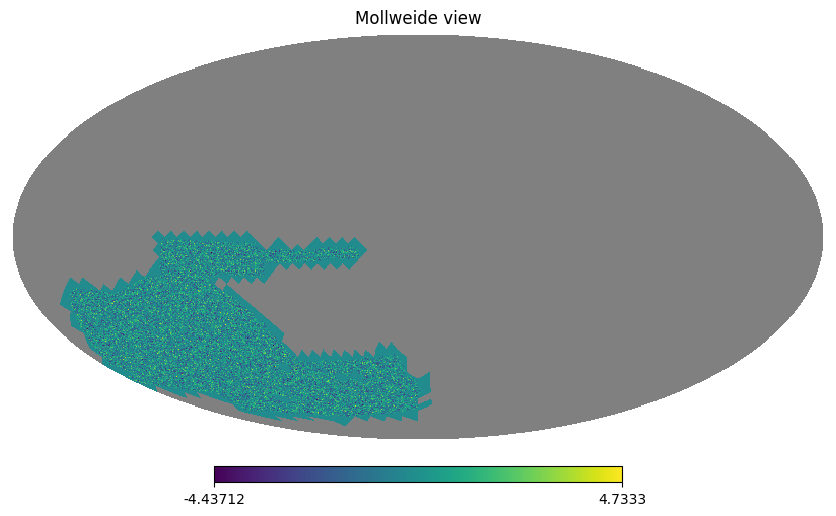

In [15]:
# create dataset
params = ["Om", "s8", "Aia", "n_Aia", "bg", "n_bg"]

fiducial_pipeline = FiducialPipeline(
    params=params,
    # shape_noise_scale=None,
    # apply_m_bias=True,
    # apply_norm=False,
    with_padding=True,
)

fiducial_dset = fiducial_pipeline.get_dset(
    tfr_pattern="/cluster/scratch/athomsen/CosmoGrid/v3/fiducial/DESy3_fiducial_???.tfrecord",
    local_batch_size=1,
    i_noise=0,
    n_readers=1,
    examples_shuffle_buffer=1,
)

# get a single batch
for data_vectors, index in fiducial_dset.take(1):
    hp_map = np.full(n_pix, hp.UNSEEN)
    hp_map[fiducial_pipeline.data_vec_pix] = data_vectors[0,:,0]
    
    hp.mollview(hp_map, nest=True)
    # print(data_vectors.shape)

23-05-22 15:01:30     files.py INF   Loaded the pixel file /cluster/home/athomsen/py3_10/repos/multiprobe-simulation-forward-model/data/DESY3_pixels_512.h5 
23-05-22 15:01:30     files.py INF   Loaded the pixel file /cluster/home/athomsen/py3_10/repos/multiprobe-simulation-forward-model/data/DESY3_pixels_512.h5 
23-05-22 15:01:30 fiducial_pip INF   Shuffling file names 
23-05-22 15:01:30 tfrecords.py WAR   Tracing parse_inverse_fiducial 
23-05-22 15:01:30 fiducial_pip INF   Batching into 1 elements locally 
23-05-22 15:01:30 fiducial_pip WAR   Tracing _augmentations 
23-05-22 15:01:31 fiducial_pip INF   Running on the data_vectors.keys() = dict_keys(['kg_fiducial', 'dg_fiducial', 'kg_delta_Om_m', 'dg_delta_Om_m', 'kg_delta_Om_p', 'dg_delta_Om_p', 'kg_delta_s8_m', 'dg_delta_s8_m', 'kg_delta_s8_p', 'dg_delta_s8_p', 'kg_delta_Aia_m', 'kg_delta_Aia_p', 'kg_delta_n_Aia_m', 'kg_delta_n_Aia_p', 'dg_delta_bg_m', 'dg_delta_bg_p', 'dg_delta_n_bg_m', 'dg_delta_n_bg_p', 'sn']) 
23-05-22 15:01:31 f

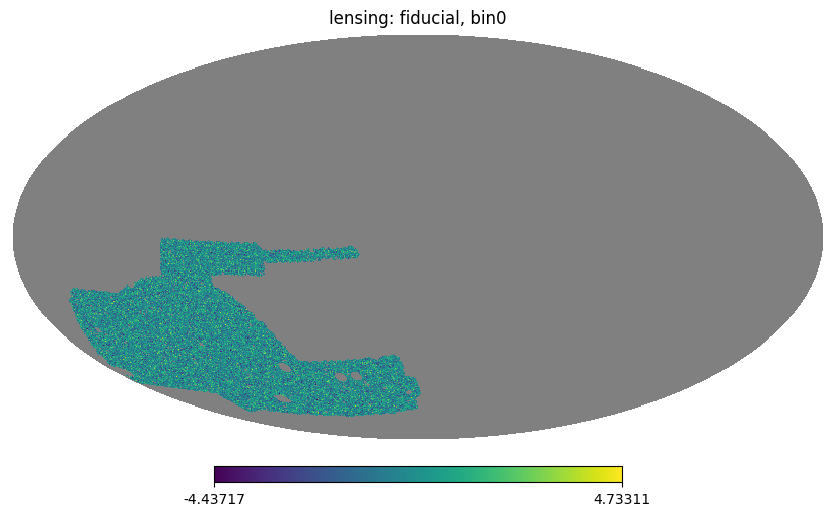

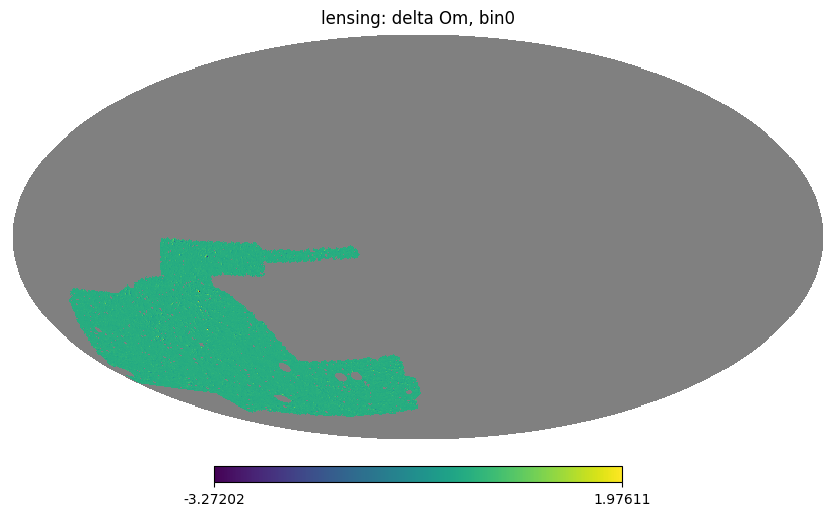

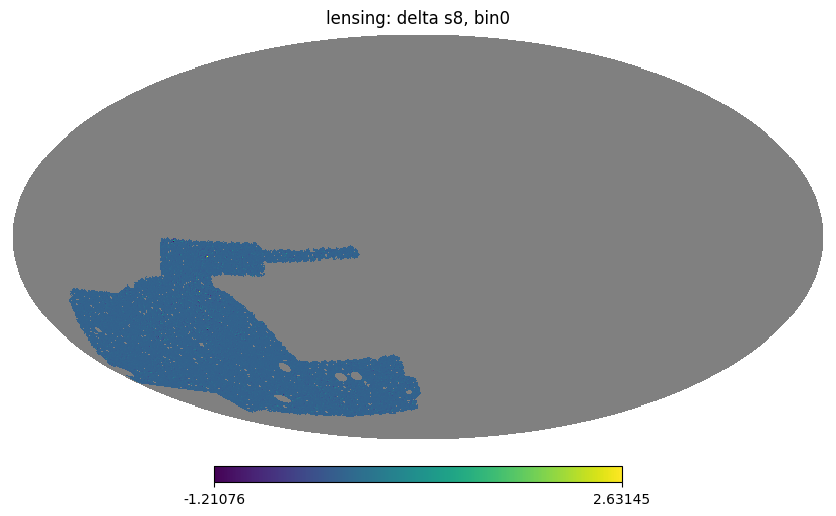

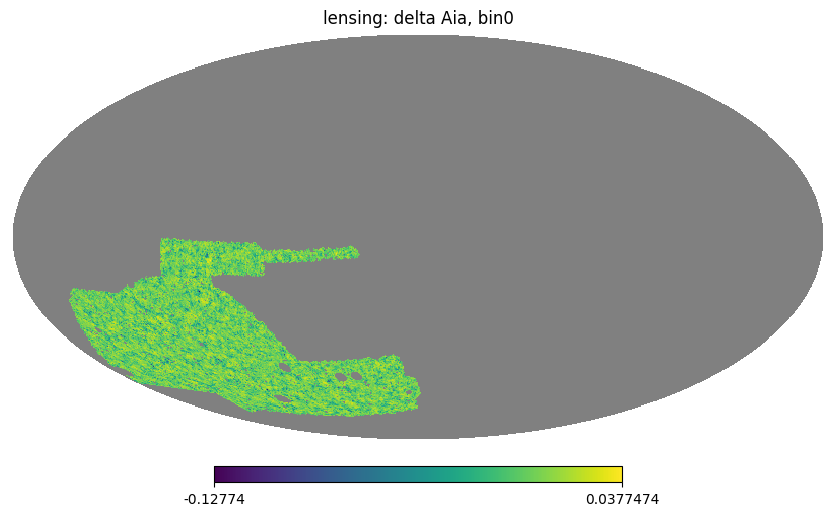

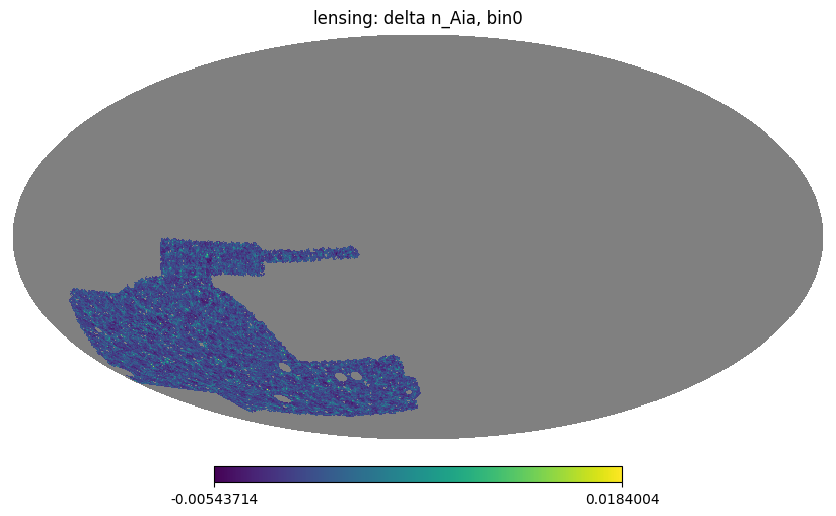

...

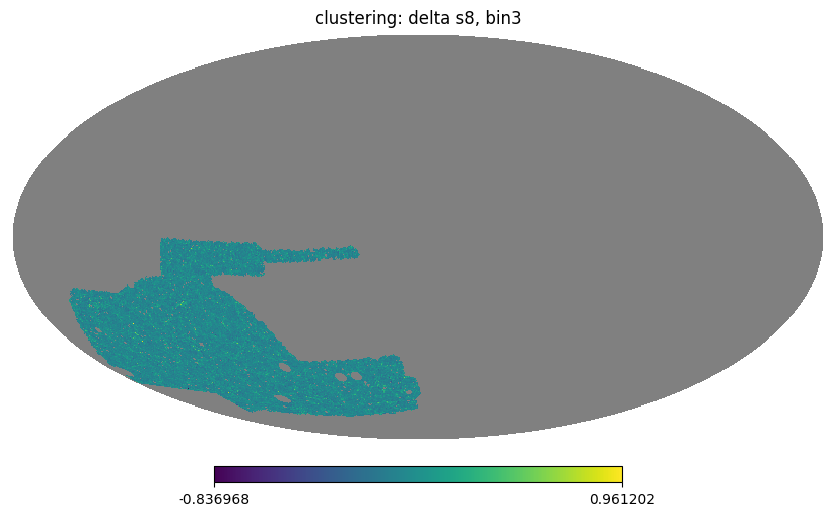

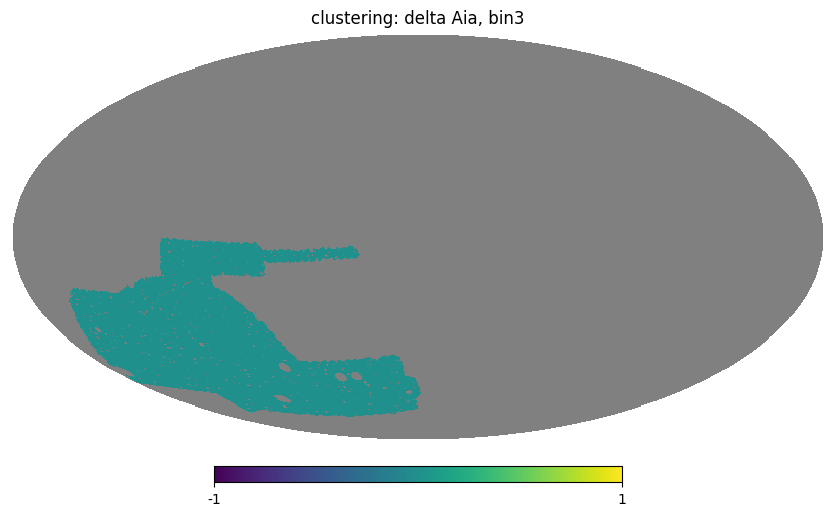

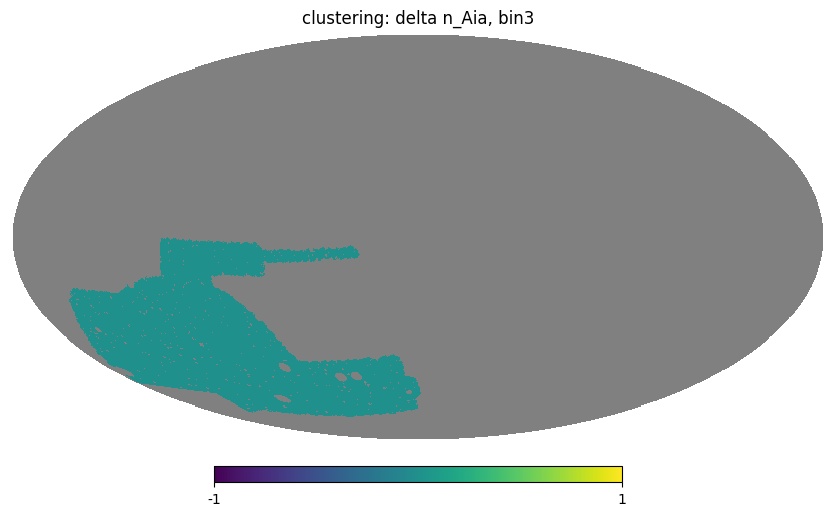

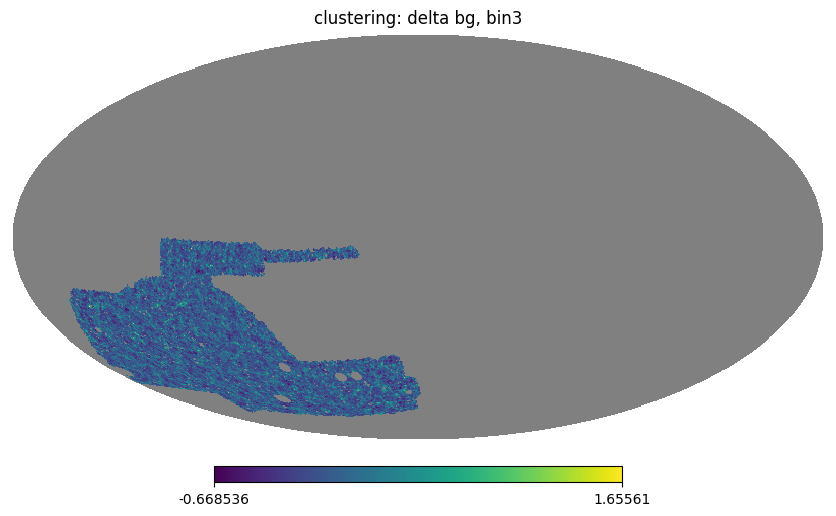

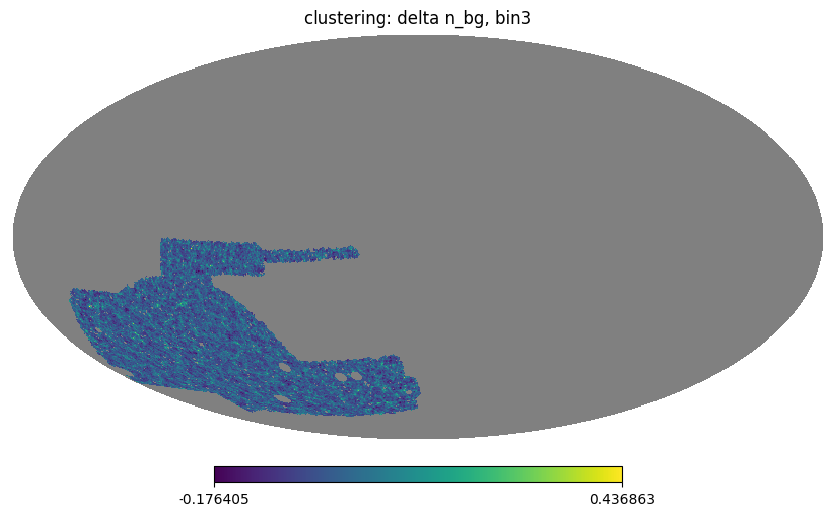

In [14]:
# create dataset
params = ["Om", "s8", "Aia", "n_Aia", "bg", "n_bg"]

fiducial_pipeline = FiducialPipeline(
    params=params,
    # shape_noise_scale=None,
    # apply_m_bias=True,
    # apply_norm=False,
    with_padding=False
)

fiducial_dset = fiducial_pipeline.get_dset(
    tfr_pattern="/cluster/scratch/athomsen/CosmoGrid/v3/fiducial/DESy3_fiducial_???.tfrecord",
    local_batch_size=1,
    i_noise=0,
    n_readers=1,
    examples_shuffle_buffer=1,
)

# get a single batch
for data_vectors, index in fiducial_dset.take(1):
    print(data_vectors.shape)

print(fiducial_pipeline.n_dv_pix)
# loop over the tomographic bin/map type
for i in range(data_vectors.shape[-1]):
    assert data_vectors.shape[-1] == 8
    
    if i < 4:
        map_type = "lensing"
        i_tomo = i
    else:
        map_type = "clustering"
        i_tomo = i - 4
        
    # loop over the parameter perturbation
    for j, param in enumerate(["fiducial"] + params):
        hp_map = np.full(n_pix, hp.UNSEEN)

        if j == 0:
            hp_map[fiducial_pipeline.patch_pix] = data_vectors[j,:,i]
            hp.mollview(hp_map, nest=True, title=f"{map_type}: fiducial, bin{i_tomo}")
            
        else:
            i_m = 2*j-1
            i_p = 2*j
            # print(f"i_m = {i_m}, i_p = {i_p}")
            # plus - minus perturbation
            hp_map[fiducial_pipeline.patch_pix] = data_vectors[i_p,:,i] - data_vectors[i_m,:,i]
            hp.mollview(hp_map, nest=True, title=f"{map_type}: delta {param}, bin{i_tomo}")


In [11]:
fiducial_pipeline.n_patch_pix

369764

In [12]:
fiducial_pipeline.patch_pix

<tf.Tensor: shape=(369764,), dtype=int32, numpy=
array([1120118, 1120119, 1120121, ..., 2954241, 2954242, 2954244],
      dtype=int32)>

In [ ]:
# create dataset
params = ["Om", "s8", "Aia", "n_Aia", "bg", "n_bg"]

fiducial_pipeline = FiducialPipeline(
    params=params,
    # shape_noise_scale=None,
    # apply_m_bias=True,
    # apply_norm=False,
)

fiducial_dset = fiducial_pipeline.get_dset(
    tfr_pattern="/cluster/scratch/athomsen/CosmoGrid/v3/fiducial/DESy3_fiducial_???.tfrecord",
    local_batch_size=1,
    i_noise=0,
    n_readers=1,
    examples_shuffle_buffer=1,
)

# get a single batch
for data_vectors, index in fiducial_dset.take(1):
    print(data_vectors.shape)

# loop over the tomographic bin/map type
for i in range(data_vectors.shape[-1]):
    assert data_vectors.shape[-1] == 8
    
    if i < 4:
        map_type = "lensing"
        i_tomo = i
    else:
        map_type = "clustering"
        i_tomo = i - 4
        
    # loop over the parameter perturbation
    for j, param in enumerate(["fiducial"] + params):
        hp_map = np.full(n_pix, hp.UNSEEN)

        if j == 0:
            hp_map[data_vec_pix] = data_vectors[j,:,i]
            hp.mollview(hp_map, nest=True, title=f"{map_type}: fiducial, bin{i_tomo}")
            
        else:
            i_m = 2*j-1
            i_p = 2*j
            # print(f"i_m = {i_m}, i_p = {i_p}")
            # plus - minus perturbation
            hp_map[data_vec_pix] = data_vectors[i_p,:,i] - data_vectors[i_m,:,i]
            hp.mollview(hp_map, nest=True, title=f"{map_type}: delta {param}, bin{i_tomo}")


In [ ]:
# create dataset
params = ["Om", "s8", "Aia", "n_Aia", "bg", "n_bg"]

fiducial_pipeline = FiducialPipeline(
    params=params,
    # shape_noise_scale=None,
    # apply_m_bias=True,
    # apply_norm=False,
)

fiducial_dset = fiducial_pipeline.get_dset(
    tfr_pattern="/cluster/scratch/athomsen/CosmoGrid/v3/fiducial/DESy3_fiducial_???.tfrecord",
    local_batch_size=1,
    i_noise=0,
    n_readers=1,
    examples_shuffle_buffer=1,
)

# get a single batch
for data_vectors, index in fiducial_dset.take(1):
    print(data_vectors.shape)

# loop over the tomographic bin/map type
for i in range(data_vectors.shape[-1]):
    assert data_vectors.shape[-1] == 8
    
    if i < 4:
        map_type = "lensing"
        i_tomo = i
    else:
        map_type = "clustering"
        i_tomo = i - 4
        
    # loop over the parameter perturbation
    for j, param in enumerate(["fiducial"] + params):
        hp_map = np.full(n_pix, hp.UNSEEN)

        if j == 0:
            hp_map[data_vec_pix] = data_vectors[j,:,i]
            hp.mollview(hp_map, nest=True, title=f"{map_type}: fiducial, bin{i_tomo}")
            
        else:
            i_m = 2*j-1
            i_p = 2*j
            # print(f"i_m = {i_m}, i_p = {i_p}")
            # plus - minus perturbation
            hp_map[data_vec_pix] = data_vectors[i_p,:,i] - data_vectors[i_m,:,i]
            hp.mollview(hp_map, nest=True, title=f"{map_type}: delta {param}, bin{i_tomo}")


# lensing only

In [6]:
# create dataset
params = ["Om", "s8", "Aia", "n_Aia"]

fiducial_dset = fiducial_pipeline.get_fiducial_dset(
    tfr_pattern="/cluster/scratch/athomsen/CosmoGrid/debug/v3/fiducial/DESy3_fiducial_???.tfrecord",
    with_clustering=False,
    local_batch_size=1,
    params=params,
    i_noise=0,
    n_readers=1,
    examples_shuffle_buffer=1,
    shape_noise_scale=None,
    poisson_noise_scale=None,
    with_m_bias=None,
)

# get a single batch
for kg_data_vectors, index in fiducial_dset.take(1):
    print(kg_data_vectors.shape)

# plot
map_type = "lensing"

# # loop over the tomographic bin/map type
# for i in range(4):
#     # loop over the parameter perturbation
#     for j, param in enumerate(["fiducial"] + params):
#         hp_map = np.full(n_pix, hp.UNSEEN)

#         if j == 0:
#             hp_map[data_vec_pix] = kg_data_vectors[j,:,i]
#             hp.mollview(hp_map, nest=True, title=f"{map_type}: fiducial, bin{i}")
            
#         else:
#             i_m = 2*j-1
#             i_p = 2*j
#             # print(f"i_m = {i_m}, i_p = {i_p}")
#             # plus - minus perturbation
#             hp_map[data_vec_pix] = kg_data_vectors[i_p,:,i] - kg_data_vectors[i_m,:,i]
#             hp.mollview(hp_map, nest=True, title=f"{map_type}: delta {param}, bin{i}")


23-05-03 09:36:55 fiducial_pip INF   Starting to generate the fiducial training set for i_noise = 0 
23-05-03 09:36:55  analysis.py INF   Loaded the config 
23-05-03 09:36:55  analysis.py INF   Loaded the config 
/cluster/home/athomsen/py3_10/repos/multiprobe-simulation-forward-model/data/DESY3_pixels_512.h5
23-05-03 09:36:55  analysis.py INF   Loaded the pixel file 
23-05-03 09:36:55  analysis.py INF   Loaded the config 
/cluster/home/athomsen/py3_10/repos/multiprobe-simulation-forward-model/data/DESY3_pixels_512.h5
23-05-03 09:36:55  analysis.py INF   Loaded the pixel file 
23-05-03 09:36:55  analysis.py INF   Loaded the config 
23-05-03 09:36:55 fiducial_pip INF   Shuffling file names 
23-05-03 09:36:55 tfrecords.py WAR   Tracing parse_inverse_fiducial 
23-05-03 09:36:55 fiducial_pip INF   Batching into 1 elements locally 
23-05-03 09:36:55 fiducial_pip WAR   Tracing dset_augmentations 
23-05-03 09:36:56 fiducial_pip INF   Running on the data_vectors.keys() = dict_keys(['kg_fiducial

# clustering only

In [7]:
# create dataset
params = ["Om", "s8", "bg", "n_bg"]

fiducial_dset = fiducial_pipeline.get_fiducial_dset(
    tfr_pattern="/cluster/scratch/athomsen/CosmoGrid/debug/v3/fiducial/DESy3_fiducial_???.tfrecord",
    with_lensing=False,
    local_batch_size=1,
    params=params,
    i_noise=0,
    n_readers=1,
    examples_shuffle_buffer=1,
    shape_noise_scale=None,
    poisson_noise_scale=None,
    with_m_bias=None,
)

# get a single batch
for dg_data_vectors, index in fiducial_dset.take(1):
    print(dg_data_vectors.shape)

# # plot
# map_type = "clustering"

# # loop over the tomographic bin/map type
# for i in range(6):        
#     # loop over the parameter perturbation
#     for j, param in enumerate(["fiducial"] + params):
#         hp_map = np.full(n_pix, hp.UNSEEN)

#         if j == 0:
#             hp_map[data_vec_pix] = dg_data_vectors[j,:,i]
#             hp.mollview(hp_map, nest=True, title=f"{map_type}: fiducial, bin{i}")
            
#         else:
#             i_m = 2*j-1
#             i_p = 2*j
#             # print(f"i_m = {i_m}, i_p = {i_p}")
#             # plus - minus perturbation
#             hp_map[data_vec_pix] = dg_data_vectors[i_p,:,i] - dg_data_vectors[i_m,:,i]
#             hp.mollview(hp_map, nest=True, title=f"{map_type}: delta {param}, bin{i}")


23-05-03 09:36:59 fiducial_pip INF   Starting to generate the fiducial training set for i_noise = 0 
23-05-03 09:36:59  analysis.py INF   Loaded the config 
23-05-03 09:36:59  analysis.py INF   Loaded the config 
/cluster/home/athomsen/py3_10/repos/multiprobe-simulation-forward-model/data/DESY3_pixels_512.h5
23-05-03 09:36:59  analysis.py INF   Loaded the pixel file 
23-05-03 09:36:59  analysis.py INF   Loaded the config 
/cluster/home/athomsen/py3_10/repos/multiprobe-simulation-forward-model/data/DESY3_pixels_512.h5
23-05-03 09:36:59  analysis.py INF   Loaded the pixel file 
23-05-03 09:36:59  analysis.py INF   Loaded the config 
23-05-03 09:36:59 fiducial_pip INF   Shuffling file names 
23-05-03 09:36:59 tfrecords.py WAR   Tracing parse_inverse_fiducial 
23-05-03 09:36:59 fiducial_pip INF   Batching into 1 elements locally 
23-05-03 09:36:59 fiducial_pip WAR   Tracing dset_augmentations 
23-05-03 09:37:00 fiducial_pip INF   Running on the data_vectors.keys() = dict_keys(['dg_fiducial

In [8]:
print(data_vectors.shape)
print(kg_data_vectors.shape)
print(dg_data_vectors.shape)

(13, 475136, 10)
(9, 475136, 4)
(9, 475136, 6)


(array([       0.,        0.,        0.,        0.,        0., 17104896.,
               0.,        0.,        0.,        0.]),
 array([-0.5, -0.4, -0.3, -0.2, -0.1,  0. ,  0.1,  0.2,  0.3,  0.4,  0.5],
       dtype=float32),
 <BarContainer object of 10 artists>)

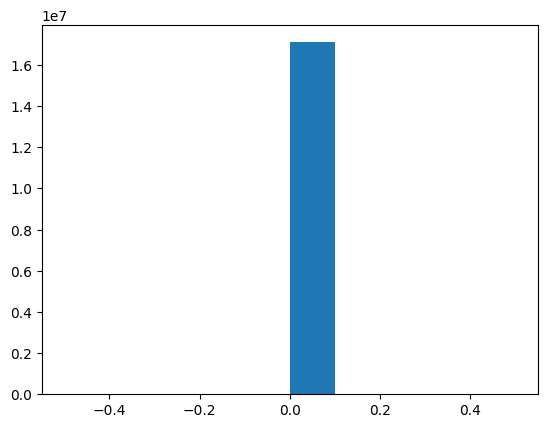

In [9]:
# lensing maps
diff = data_vectors[:9, :, :4] - kg_data_vectors
diff = diff.numpy().ravel()
plt.hist(diff)

In [10]:
np.all(data_vectors[:5, :, 4:] == dg_data_vectors[:5, :, :])

True

(array([       0.,        0.,        0.,        0.,        0., 14254080.,
               0.,        0.,        0.,        0.]),
 array([-0.5, -0.4, -0.3, -0.2, -0.1,  0. ,  0.1,  0.2,  0.3,  0.4,  0.5],
       dtype=float32),
 <BarContainer object of 10 artists>)

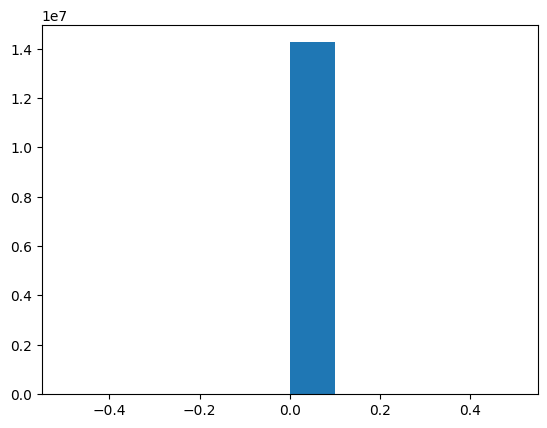

In [11]:
# clustering maps

# cosmo params
diff = data_vectors[:5, :, 4:] - dg_data_vectors[:5, :, :]
diff = diff.numpy().ravel()
plt.hist(diff)

# # clustering params
# diff = data_vectors[9:, :, 4:] - dg_data_vectors[5:, :, :]
# diff = diff.numpy().ravel()
# plt.hist(diff)

# old

In [4]:
params = ["Om", "s8", "Aia", "n_Aia", "bg", "n_bg"]

fiducial_dset = fiducial_pipeline.get_fiducial_dset(
    tfr_pattern="/cluster/scratch/athomsen/CosmoGrid/debug/v3/fiducial/DESy3_fiducial_???.tfrecord",
    local_batch_size=1,
    params=params,
    i_noise=0,
    n_readers=1,
    examples_shuffle_buffer=1,
)

23-05-02 14:58:46 fiducial_pip INF   Starting to generate the fiducial training set for i_noise = 0 
23-05-02 14:58:46  analysis.py INF   Loaded the config 
23-05-02 14:58:46  analysis.py INF   Loaded the config 
23-05-02 14:58:46  analysis.py INF   Loaded the config 
23-05-02 14:58:46  analysis.py INF   Loaded the config 
/cluster/home/athomsen/py3_10/repos/multiprobe-simulation-forward-model/data/DESY3_pixels_512.h5
23-05-02 14:58:46  analysis.py INF   Loaded the pixel file 
23-05-02 14:58:46  analysis.py INF   Loaded the config 
/cluster/home/athomsen/py3_10/repos/multiprobe-simulation-forward-model/data/DESY3_pixels_512.h5
23-05-02 14:58:46  analysis.py INF   Loaded the pixel file 
23-05-02 14:58:46 fiducial_pip INF   Shuffling file names 
23-05-02 14:58:46 tfrecords.py WAR   Tracing parse_inverse_fiducial 
23-05-02 14:58:46 fiducial_pip INF   Batching into 1 elements locally 
23-05-02 14:58:47 fiducial_pip INF   new function 
23-05-02 14:58:47 fiducial_pip INF   Successfully gener

In [5]:
for data_vectors, index in fiducial_dset.take(1):
    print(data_vectors.shape)

(13, 475136, 10)


In [6]:
data_vec_pix, _, _, _ = analysis.load_pixel_file()
n_side = 512
n_pix = hp.nside2npix(n_side)

23-05-02 14:58:55  analysis.py INF   Loaded the config 
/cluster/home/athomsen/py3_10/repos/multiprobe-simulation-forward-model/data/DESY3_pixels_512.h5
23-05-02 14:58:55  analysis.py INF   Loaded the pixel file 


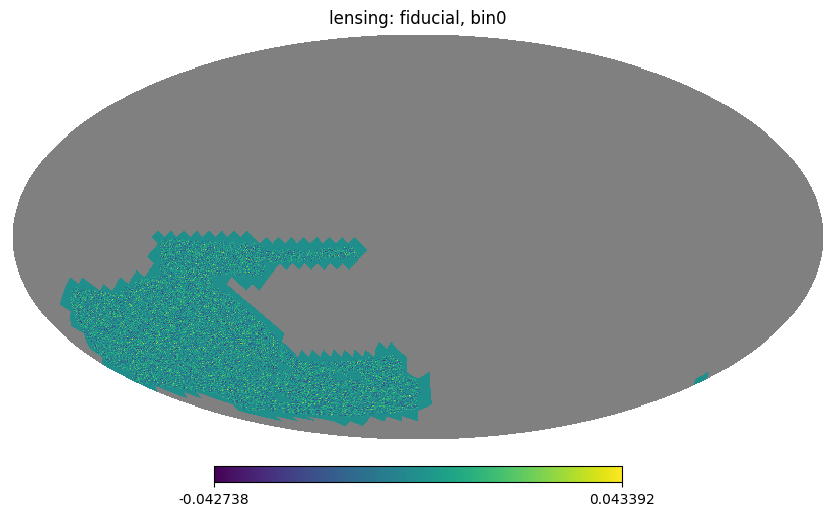

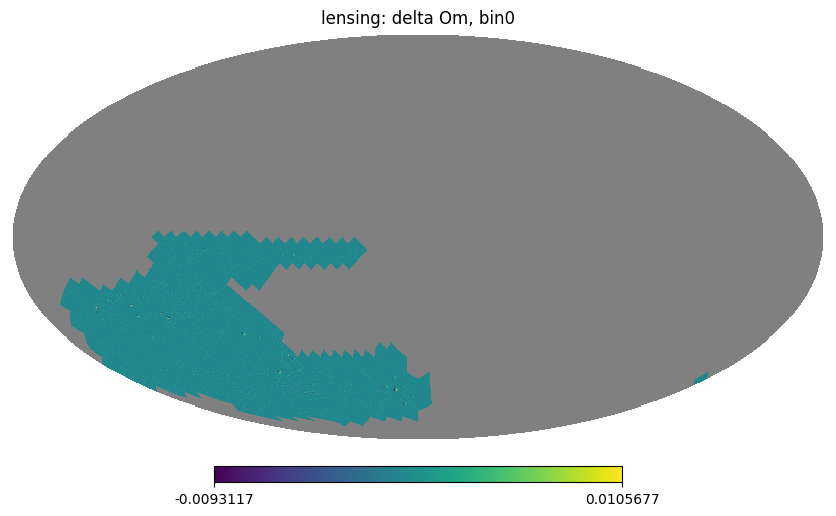

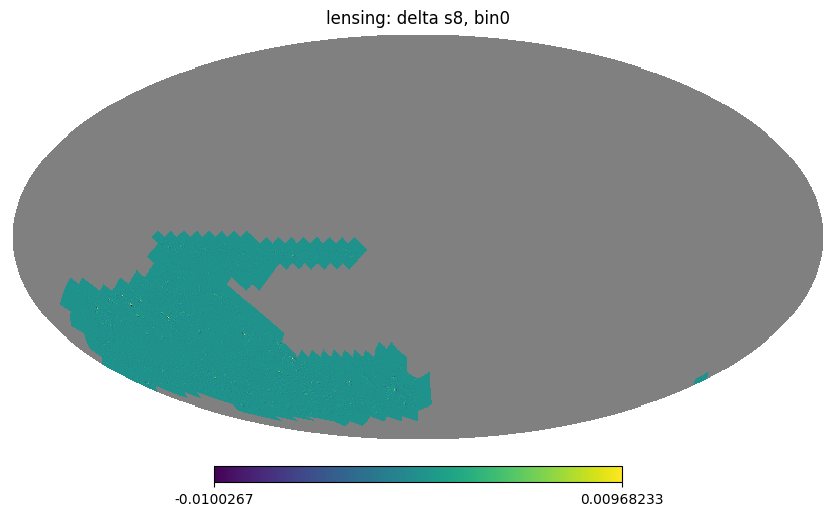

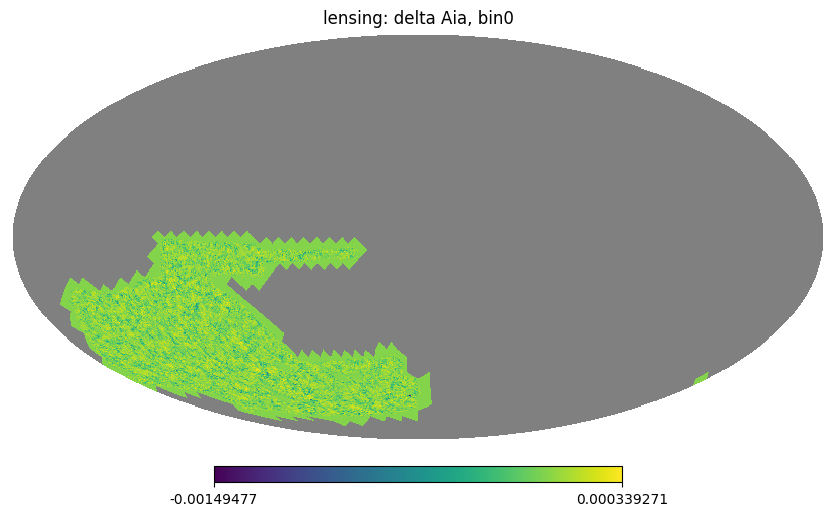

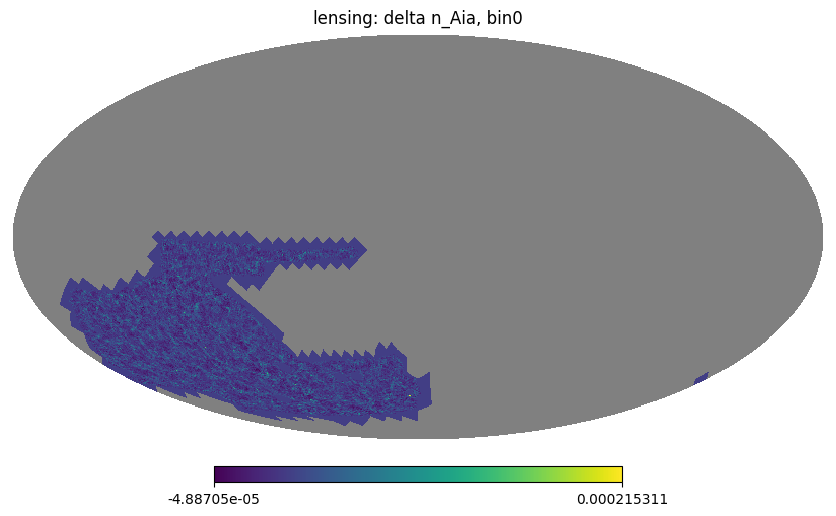

...

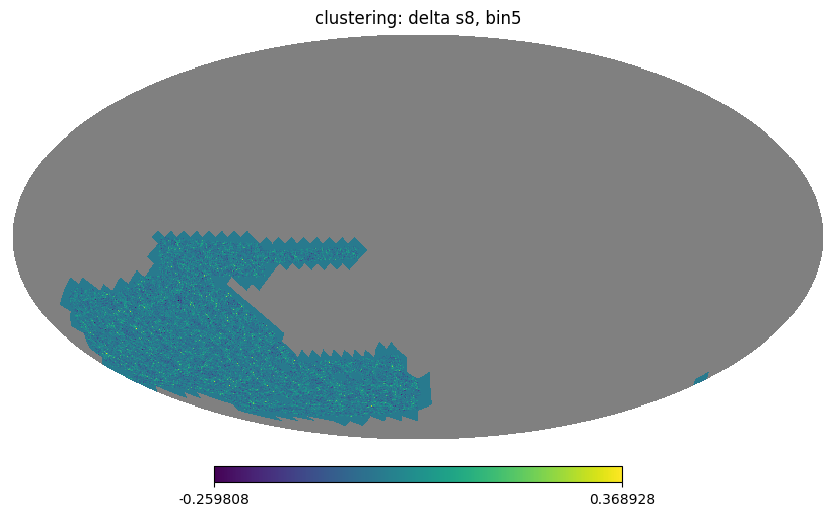

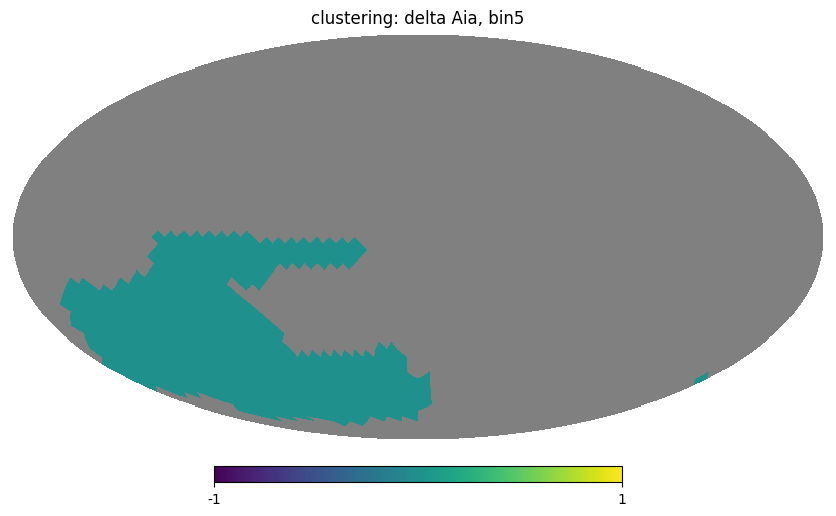

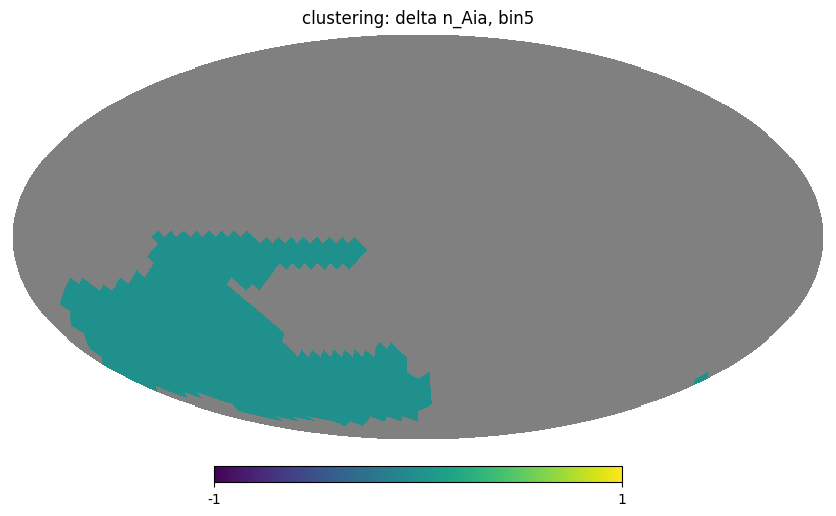

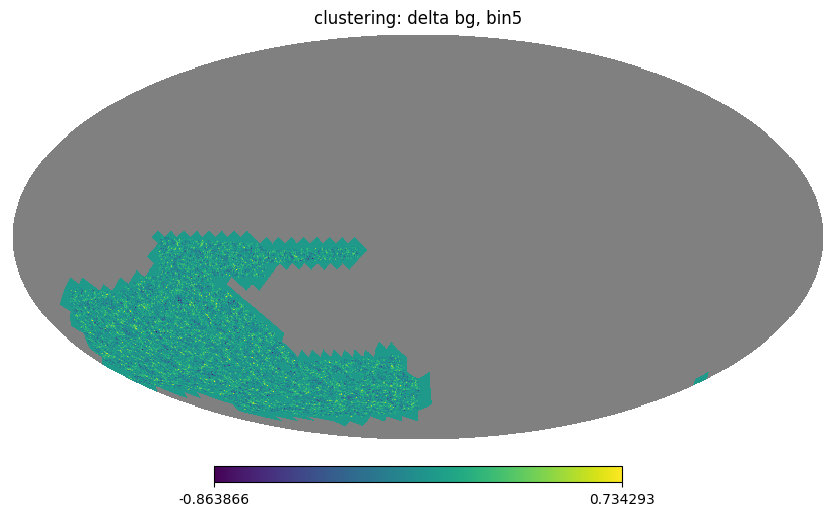

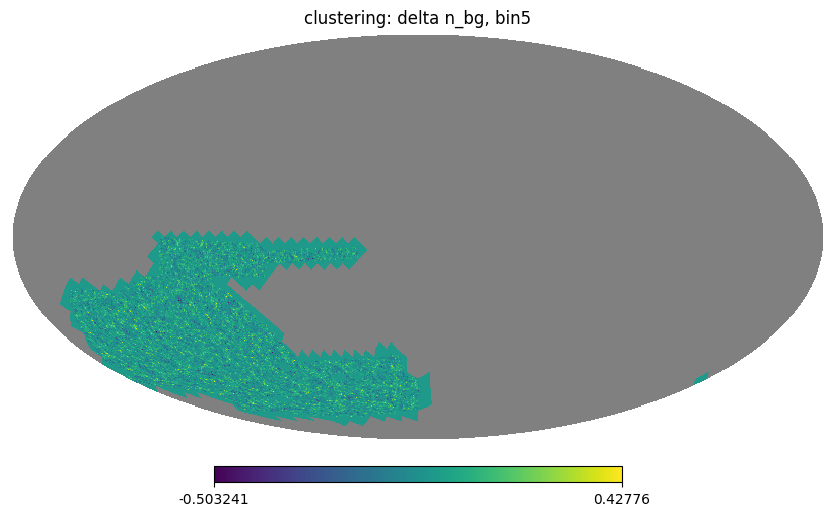

In [7]:
# loop over the tomographic bin/map type
for i in range(10):
    if i < 4:
        map_type = "lensing"
        i_tomo = i
    else:
        map_type = "clustering"
        i_tomo = i - 4
        
    # loop over the parameter perturbation
    for j, param in enumerate(["fiducial"] + params):
        hp_map = np.full(n_pix, hp.UNSEEN)

        if j == 0:
            hp_map[data_vec_pix] = data_vectors[j,:,i]
            hp.mollview(hp_map, nest=True, title=f"{map_type}: fiducial, bin{i_tomo}")
            
        else:
            i_m = 2*j-1
            i_p = 2*j
            # print(f"i_m = {i_m}, i_p = {i_p}")
            # plus - minus perturbation
            hp_map[data_vec_pix] = data_vectors[i_p,:,i] - data_vectors[i_m,:,i]
            hp.mollview(hp_map, nest=True, title=f"{map_type}: delta {param}, bin{i_tomo}")

    

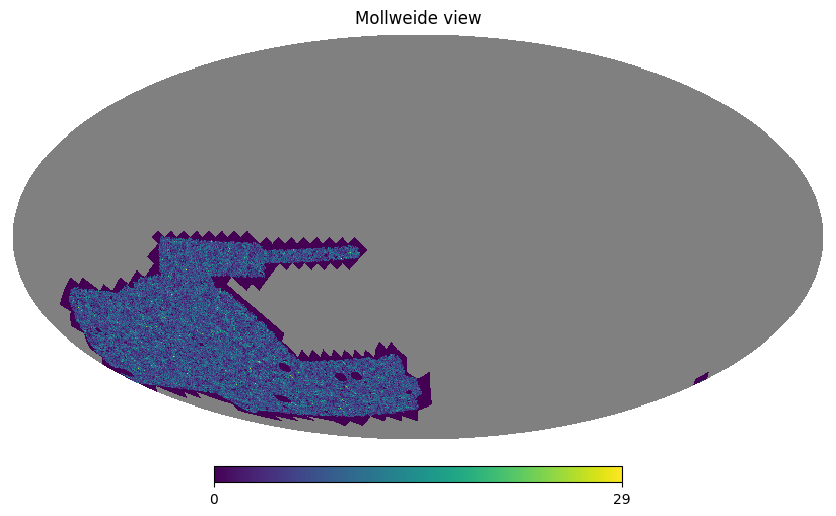

In [104]:
hp_map = np.full(n_pix, hp.UNSEEN)
hp_map[data_vec_pix] = data_vectors[0,:,4]

hp.mollview(hp_map, nest=True)

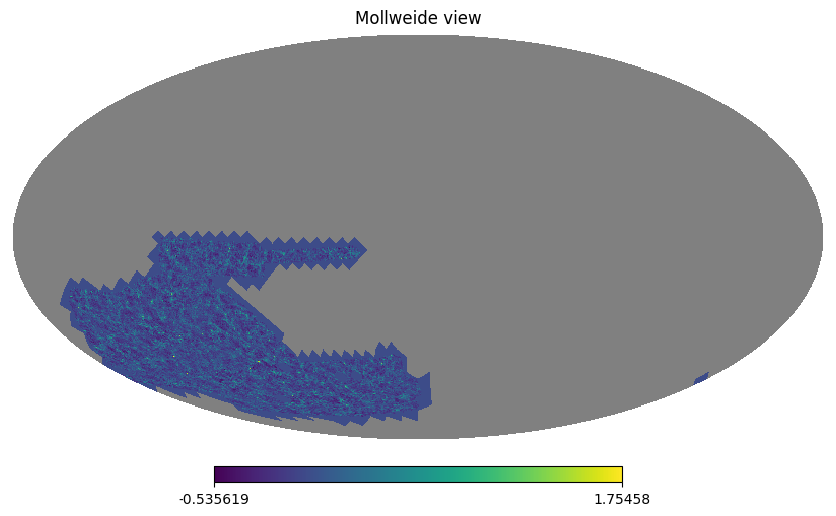

In [106]:
hp_map = np.full(n_pix, hp.UNSEEN)
hp_map[data_vec_pix] = data_vectors[-2,:,4] - data_vectors[-1,:,4]

hp.mollview(hp_map, nest=True)

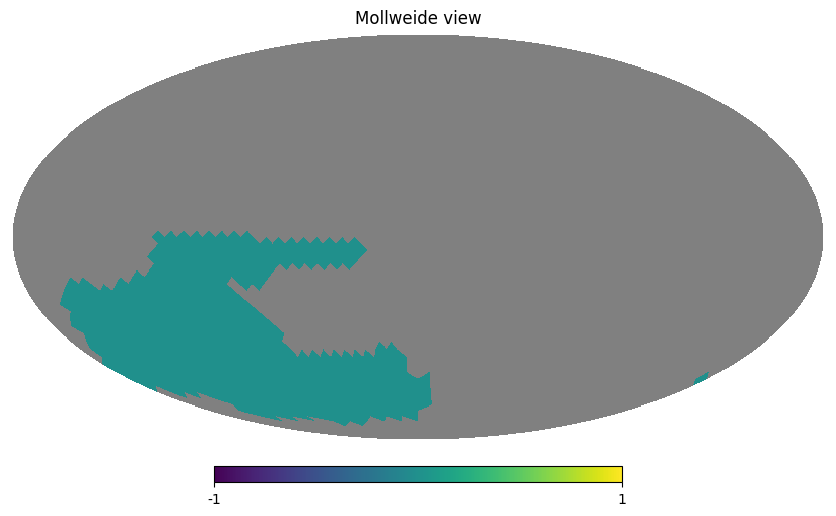

In [105]:
hp_map = np.full(n_pix, hp.UNSEEN)
hp_map[data_vec_pix] = data_vectors[0,:,4] - data_vectors[-5,:,4]

hp.mollview(hp_map, nest=True)

(array([1.00635e+05, 2.16701e+05, 1.38555e+05, 1.69100e+04, 1.95100e+03,
        3.12000e+02, 5.00000e+01, 1.20000e+01, 7.00000e+00, 3.00000e+00]),
 array([ 0.       ,  3.5869262,  7.1738524, 10.760778 , 14.347705 ,
        17.934631 , 21.521557 , 25.108484 , 28.69541  , 32.282337 ,
        35.869263 ], dtype=float32),
 <BarContainer object of 10 artists>)

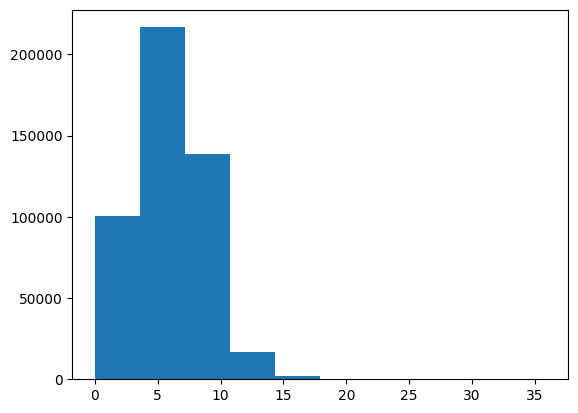

In [71]:
plt.hist(data_vectors[0,:,4].numpy())

In [3]:
conf_dir = "../../configs/config.yaml"
conf = read_yaml(conf_dir)

tfr_pattern = "/cluster/scratch/athomsen/CosmoGrid/debug/v3/fiducial/DESy3_fiducial_???.tfrecord"
# tfr_pattern = "/Users/arne/data/DESY3/tfrecords/debug/v2/DESy3_fiducial_000.tfrecord"

params = ["Om", "s8", "Aia"]
pert_labels = parameters.get_fiducial_perturbation_labels(params)
n_perts = len(pert_labels)
print(n_perts, pert_labels)

n_z_bins = 4

batch_size = 4
examples_shuffle_buffer = 10
n_readers = 1
n_prefetch = 3

7 ['fiducial', 'delta_Om_m', 'delta_Om_p', 'delta_s8_m', 'delta_s8_p', 'delta_Aia_m', 'delta_Aia_p']


In [5]:
fiducial_dset = fiducial_pipeline.get_fiducial_dset(
    tfr_pattern,
    pert_labels,
    batch_size,
    conf=None,
    i_noise=0,
    n_readers=n_readers,
    n_prefetch=n_prefetch,
    examples_shuffle_buffer=examples_shuffle_buffer,
)

23-04-27 14:32:42 fiducial_pip INF   Starting to generate the fiducial training set for i_noise = 0 
23-04-27 14:32:42  analysis.py INF   Loaded the config 
/cluster/home/athomsen/py3_10/repos/multiprobe-simulation-forward-model/data/DESY3_pixels_512.h5
23-04-27 14:32:42  analysis.py INF   Loaded the pixel file 
23-04-27 14:32:42  analysis.py INF   Loaded the config 
/cluster/home/athomsen/py3_10/repos/multiprobe-simulation-forward-model/data/DESY3_pixels_512.h5
23-04-27 14:32:42  analysis.py INF   Loaded the pixel file 


TypeError: 'int' object is not iterable

In [ ]:
t0 = time()
delta_t = []
for x in fiducial_dset.take(100):
    t1 = time()
    delta_t.append(t1 - t0)
    t0 = t1

fig, ax = plt.subplots(figsize=(20, 4))
ax.plot(delta_t)

In [7]:
multi_noise_dset = fiducial_pipeline.get_fiducial_multi_noise_dset(
    tfr_pattern,
    pert_labels,
    batch_size,
    conf=None,
    n_noise=3,
    n_readers=n_readers,
    n_prefetch=n_prefetch,
    examples_shuffle_buffer=examples_shuffle_buffer,
)

23-02-22 12:36:50 fiducial_pip INF   Starting to generate the fiducial training set for i_noise = 0 
23-02-22 12:36:50  analysis.py INF   Loaded the config 
23-02-22 12:36:50  analysis.py INF   Loaded the pixel file 
23-02-22 12:36:50  analysis.py INF   Loaded the config 
23-02-22 12:36:50  analysis.py INF   Loaded the pixel file 
23-02-22 12:36:50 tfrecords.py WAR   Tracing parse_inverse_fiducial 
23-02-22 12:36:50  analysis.py INF   Loaded the config 
23-02-22 12:36:50 fiducial_pip WAR   Tracing dset_add_bias 
23-02-22 12:36:50 fiducial_pip WAR   Tracing dset_add_noise 
23-02-22 12:36:50 fiducial_pip WAR   Tracing dset_concat_perts 
23-02-22 12:36:50 fiducial_pip INF   Successfully generated the fiducial training set with element_spec (TensorSpec(shape=(28, 463872, 4), dtype=tf.float32, name=None), (TensorSpec(shape=(4,), dtype=tf.int64, name=None), TensorSpec(shape=(4,), dtype=tf.int32, name=None))) for i_noise = 0 
23-02-22 12:36:50 fiducial_pip INF   Starting to generate the fiduc

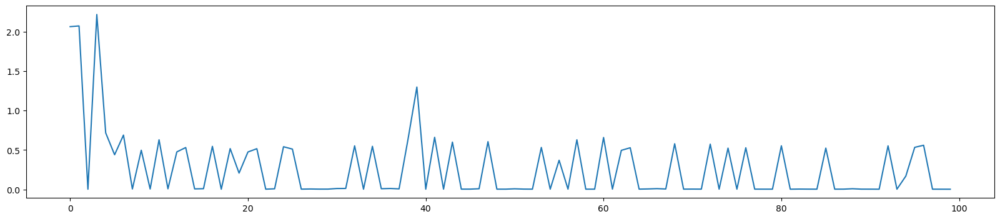

In [8]:
t0 = time()
delta_t = []
for x in multi_noise_dset.take(100):
    t1 = time()
    delta_t.append(t1 - t0)
    t0 = t1

fig, ax = plt.subplots(figsize=(20, 4))
ax.plot(delta_t)

### pick an example batch

In [9]:
for x in fiducial_dset.take(1):
    x
    
print(x)

(<tf.Tensor: shape=(28, 463872, 4), dtype=float32, numpy=
array([[[0., 0., 0., 0.],
        [0., 0., 0., 0.],
        [0., 0., 0., 0.],
        ...,
        [0., 0., 0., 0.],
        [0., 0., 0., 0.],
        [0., 0., 0., 0.]],

       [[0., 0., 0., 0.],
        [0., 0., 0., 0.],
        [0., 0., 0., 0.],
        ...,
        [0., 0., 0., 0.],
        [0., 0., 0., 0.],
        [0., 0., 0., 0.]],

       [[0., 0., 0., 0.],
        [0., 0., 0., 0.],
        [0., 0., 0., 0.],
        ...,
        [0., 0., 0., 0.],
        [0., 0., 0., 0.],
        [0., 0., 0., 0.]],

       ...,

       [[0., 0., 0., 0.],
        [0., 0., 0., 0.],
        [0., 0., 0., 0.],
        ...,
        [0., 0., 0., 0.],
        [0., 0., 0., 0.],
        [0., 0., 0., 0.]],

       [[0., 0., 0., 0.],
        [0., 0., 0., 0.],
        [0., 0., 0., 0.],
        ...,
        [0., 0., 0., 0.],
        [0., 0., 0., 0.],
        [0., 0., 0., 0.]],

       [[0., 0., 0., 0.],
        [0., 0., 0., 0.],
        [0., 0., 0., 0

### check the mask

In [12]:
data_vec_pix, _, _, tomo_patches_pix, tomo_corresponding_pix = analysis.load_pixel_file(conf)

kgs = x[0][0]
print(kgs.shape)

print([np.sum(kgs[:,i] != 0) for i in range(4)])
print([len(patches_pix[0]) for patches_pix in tomo_patches_pix])
print([len(patches_pix) for patches_pix in tomo_corresponding_pix])

23-02-22 12:37:52  analysis.py INF   Loaded the config 
23-02-22 12:37:52  analysis.py INF   Loaded the pixel file 
(463872, 4)
[371012, 370979, 370982, 370671]
[371012, 370979, 370982, 370671]
[371012, 370979, 370982, 370671]


# plotting

In [13]:
pix_file = "../../data/DESY3_pixels_512.h5"
with h5py.File(pix_file, "r") as f:
    data_vec_pix = f["metacal/map_cut_outs/data_vec_ids"][:]
    non_tomo_patches_pix = f["metacal/masks/RING/non_tomo"][:]
    
n_side = conf["analysis"]["n_side"]
n_pix = conf["analysis"]["n_pix"]

### check the masking

(463872,)
(463872,)
(463872,)
(463872,)


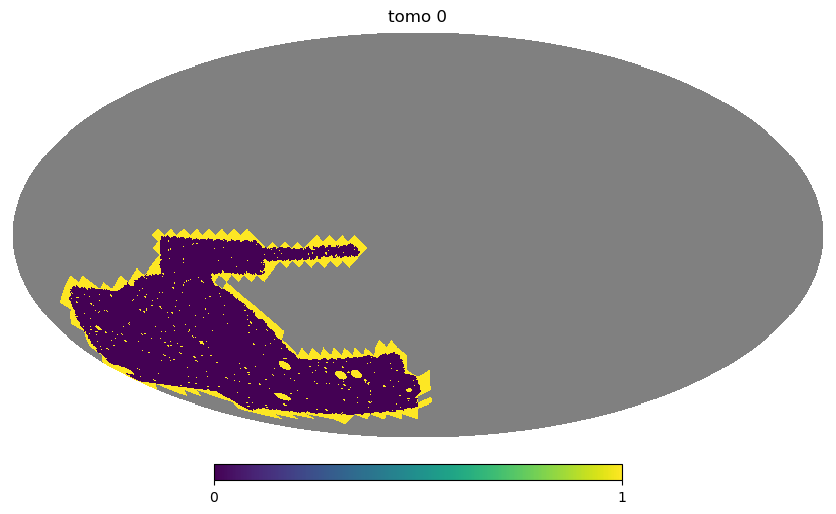

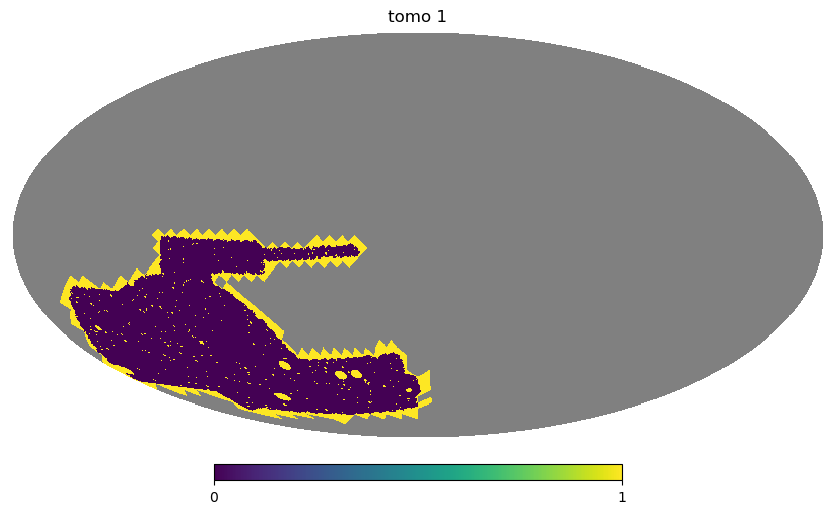

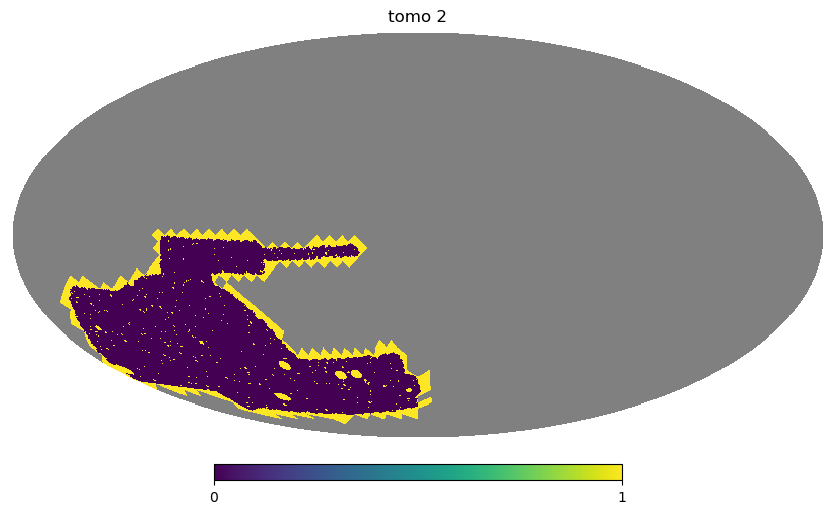

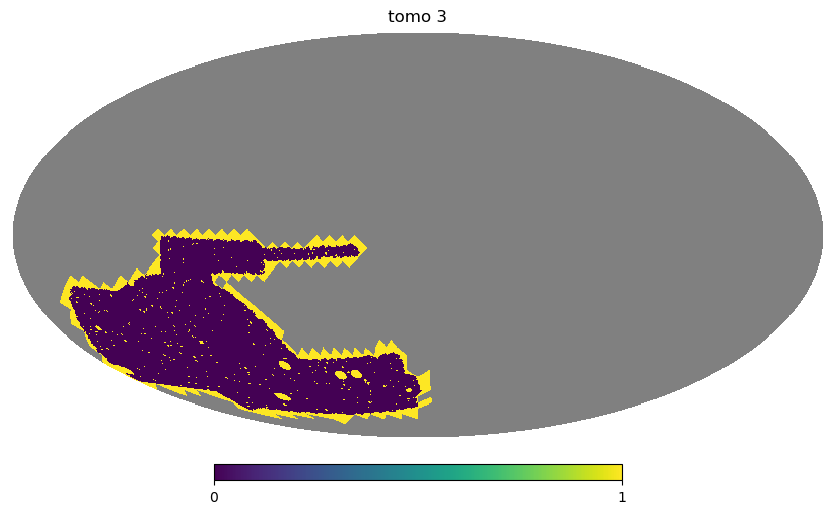

In [14]:
i_pert = 0
for i_tomo in range(n_z_bins):
    kg = x[0].numpy()[i_pert,:,i_tomo]
    print(kg.shape)

    hp_map = np.full(n_pix, hp.UNSEEN)
    hp_map[data_vec_pix] = kg

    # hp.mollview(hp_map, nest=True, title=f"tomo {i_tomo}")

    hp_mask = np.full(n_pix, hp.UNSEEN)
    hp_mask[hp_map == 0] = 1
    hp_mask[(hp_map != 0) & (hp_map != hp.UNSEEN)] = 0

    hp.mollview(hp_mask, nest=True, title=f"tomo {i_tomo}")

### check smoothed maps

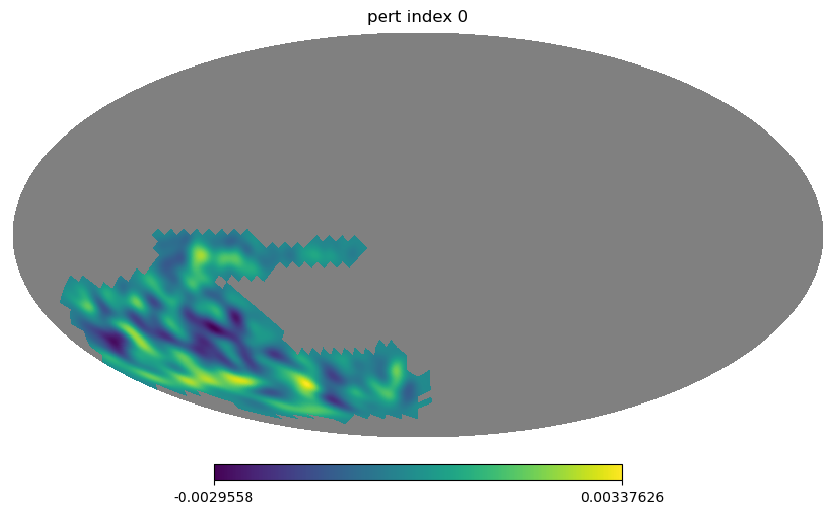

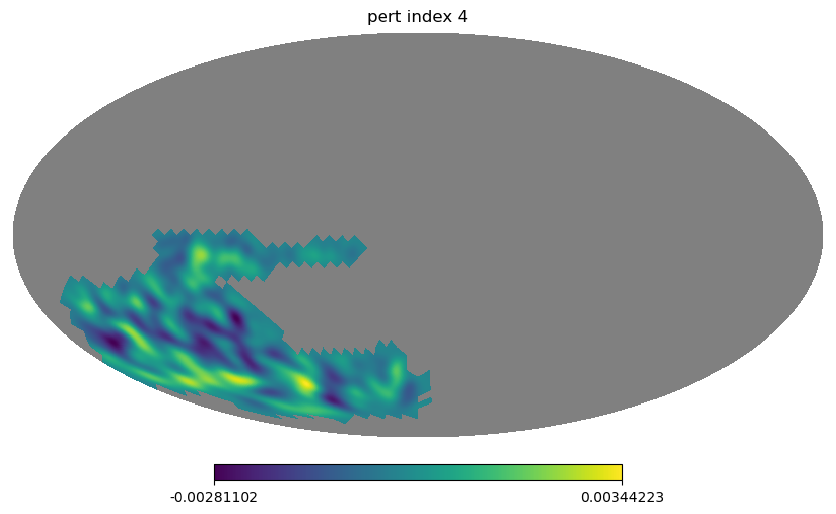

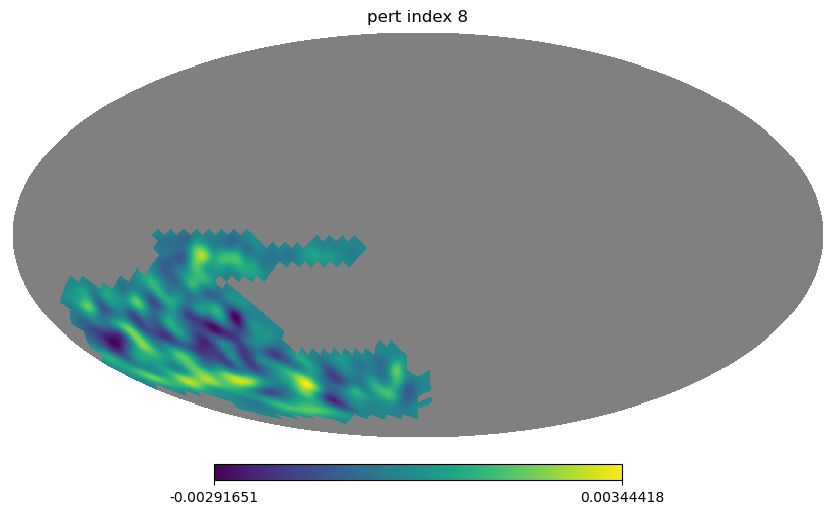

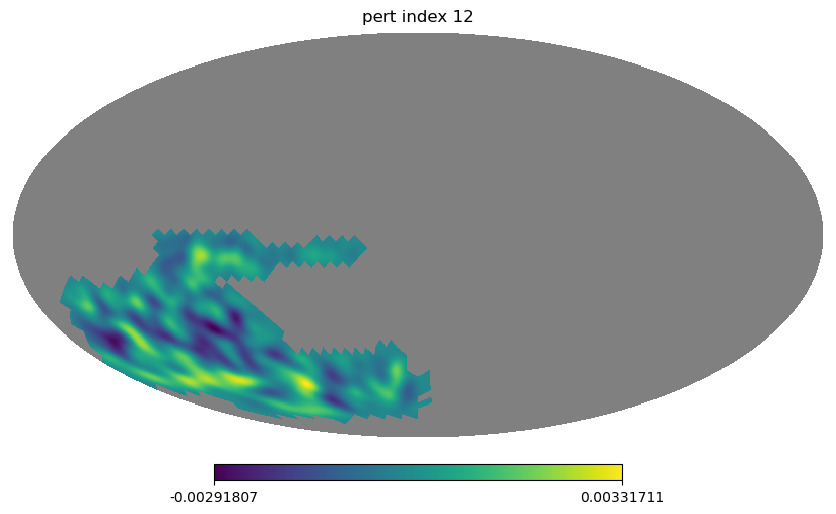

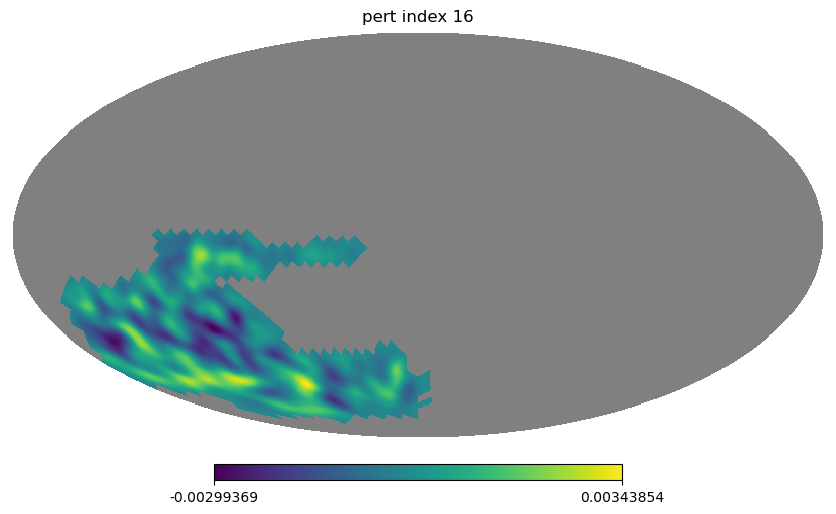

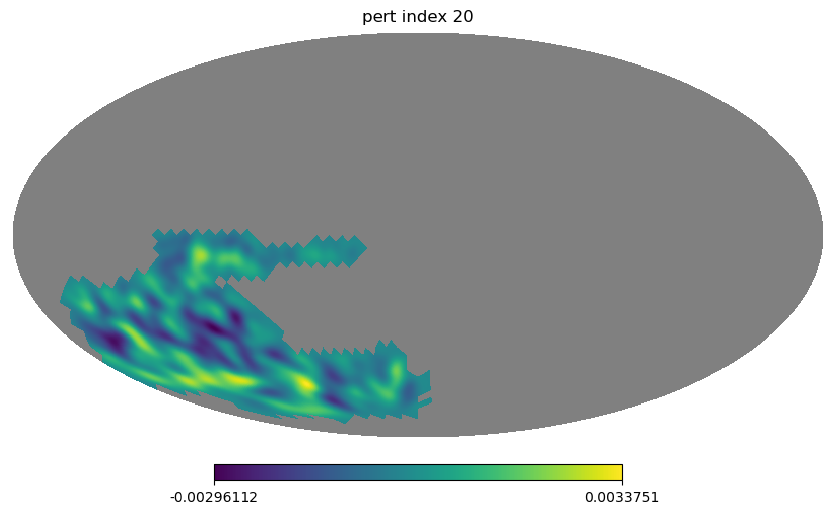

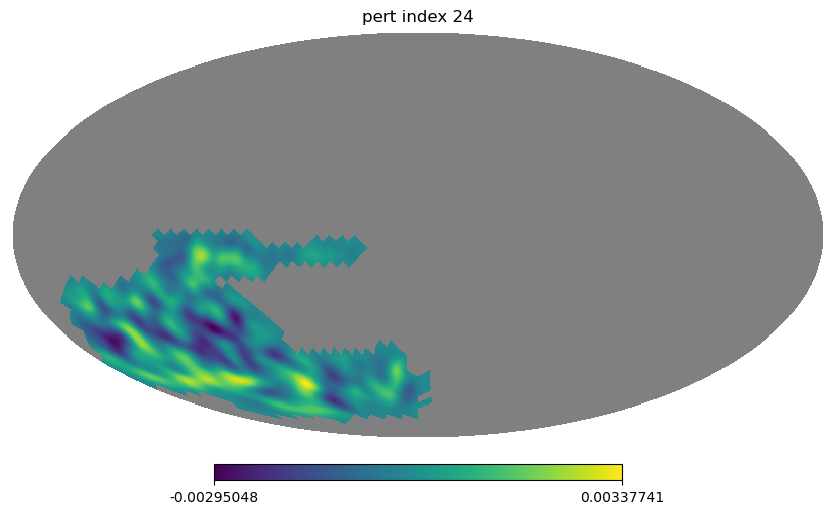

In [15]:
i_tomo = 3

for i_pert in range(0, n_perts*batch_size, batch_size):
    hp_map = np.full(n_pix, hp.UNSEEN)
    hp_map[data_vec_pix] = x[0].numpy()[i_pert,:,i_tomo]

    hp_map_ring = hp.pixelfunc.reorder(hp_map, inp="NESTED", out="RING")
    hp_smoothed = hp.sphtfunc.smoothing(hp_map_ring, fwhm=0.1)
    hp.mollview(hp_smoothed, title=f"pert index {i_pert}")

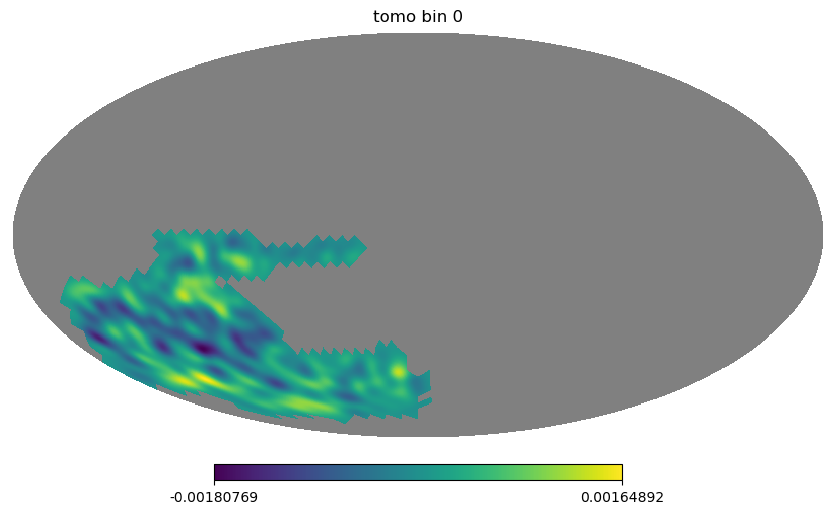

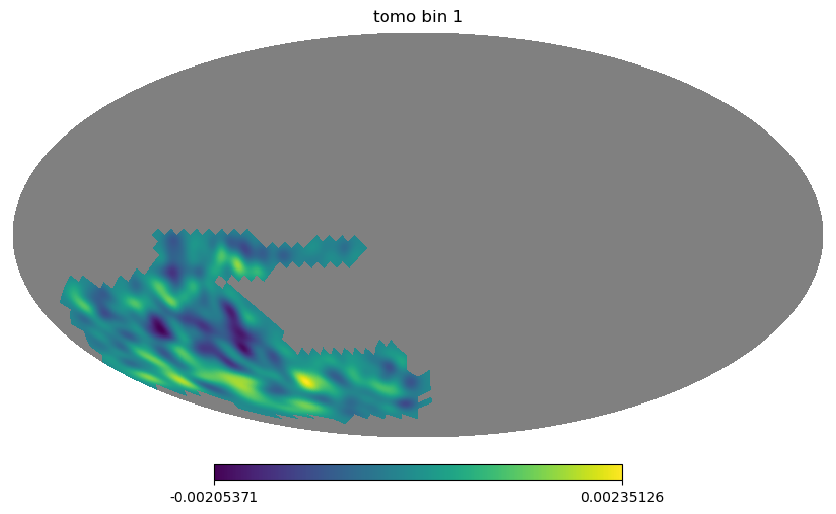

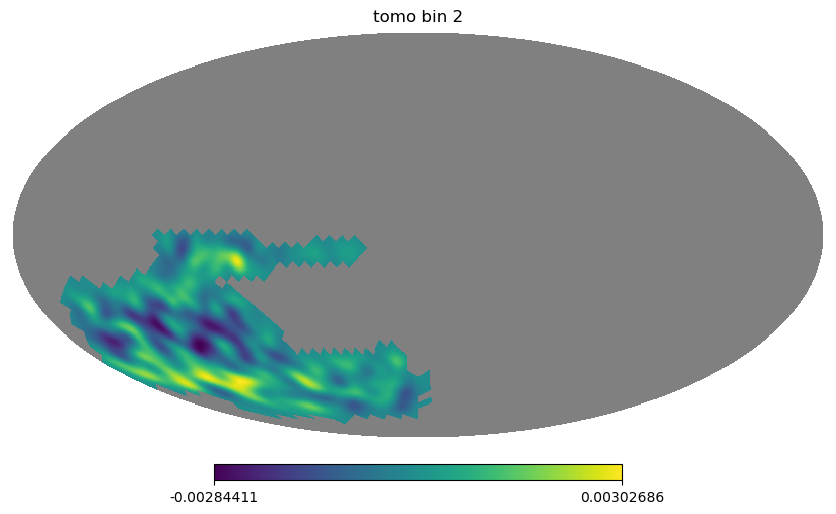

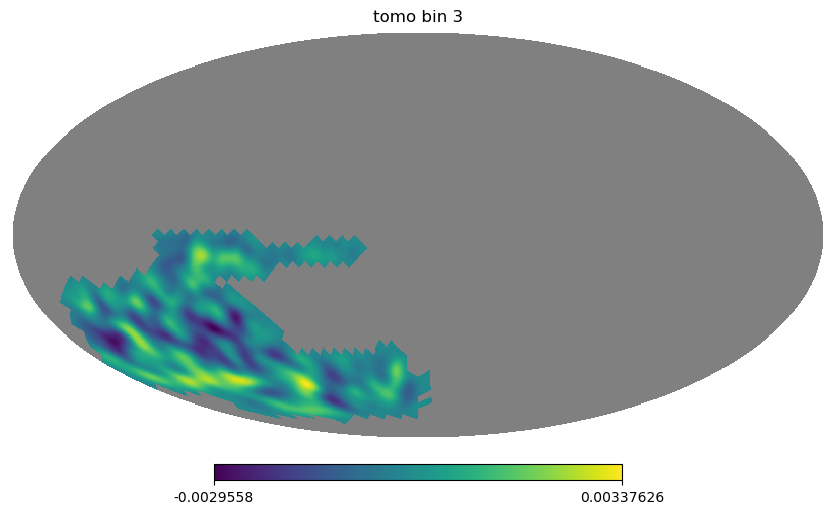

In [16]:
i_pert = 0

for i_tomo in range(n_z_bins):
    hp_map = np.full(n_pix, hp.UNSEEN)
    hp_map[data_vec_pix] = x[0].numpy()[i_pert,:,i_tomo]

    hp_map_ring = hp.pixelfunc.reorder(hp_map, inp="NESTED", out="RING")
    hp_smoothed = hp.sphtfunc.smoothing(hp_map_ring, fwhm=0.1)
    hp.mollview(hp_smoothed, title=f"tomo bin {i_tomo}")